In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Managementr
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Targets: P_solar_total, Vbat, Tbatt
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print("\nRandom Forest Algorithm Summary:")
print("  - Ensemble of Decision Trees trained via Bootstrap Aggregation (Bagging)")
print("  - Each tree trained on a random subset of data AND random subset of features")
print("  - Final prediction = average of all tree predictions")
print("  - Reduces overfitting compared to a single Decision Tree")
print("  - Key hyperparameters: n_estimators, max_depth, max_features")
print("  - Unique advantage: Out-of-Bag (OOB) error for free validation")

All libraries imported successfully

Random Forest Algorithm Summary:
  - Ensemble of Decision Trees trained via Bootstrap Aggregation (Bagging)
  - Each tree trained on a random subset of data AND random subset of features
  - Final prediction = average of all tree predictions
  - Reduces overfitting compared to a single Decision Tree
  - Key hyperparameters: n_estimators, max_depth, max_features
  - Unique advantage: Out-of-Bag (OOB) error for free validation


In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sabarivarhman G M\Downloads\ML_proj\TSURU_cleaned.csv")

df.head()

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Target-specific leakage-free feature sets (established in Notebook 03)
FEATURES_SOLAR = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_VBAT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_TBATT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

tscv      = TimeSeriesSplit(n_splits=5)
# Note: StandardScaler intentionally omitted for Random Forest
# RF uses threshold-based splits — feature scaling has zero effect on results
# This differs from Linear, Ridge, Lasso, ElasticNet, KNN which all required scaling
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

datasets = {
    'Primary'  : (df[FEATURES_SOLAR], df[TARGET_PRIMARY],   FEATURES_SOLAR),
    'Secondary': (df[FEATURES_VBAT],  df[TARGET_SECONDARY], FEATURES_VBAT),
    'Tertiary' : (df[FEATURES_TBATT], df[TARGET_TERTIARY],  FEATURES_TBATT)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")
print(f"\nFeature sets (leakage-free):")
print(f"  P_solar_total : {len(FEATURES_SOLAR)} features (currents removed)")
print(f"  Vbat          : {len(FEATURES_VBAT)} features (Vbat removed from inputs)")
print(f"  Tbatt         : {len(FEATURES_TBATT)} features (DeltaT removed)")

Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size : 19383
Test size  : 3876

Feature sets (leakage-free):
  P_solar_total : 12 features (currents removed)
  Vbat          : 12 features (Vbat removed from inputs)
  Tbatt         : 13 features (DeltaT removed)


In [ ]:
# ============================================================
# SECTION 2: BASE MODEL — DEFAULT PARAMETERS
# n_estimators=100, max_depth=None, max_features='sqrt'
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — Random Forest (default parameters)")
print("  n_estimators = 100")
print("  max_depth    = None (trees grow fully)")
print("  max_features = sqrt (sqrt of total features per split)")
print("  oob_score    = True (free validation on unsampled data)")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2      = r2_score(y_test, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
    mae     = mean_absolute_error(y_test, y_pred)
    mse     = mean_squared_error(y_test, y_pred)
    oob     = model.oob_score_
    train_r2 = r2_score(y_train, model.predict(X_train))

    results_before[name] = {
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse,
        'OOB': oob, 'train_r2': train_r2,
        'y_pred': y_pred, 'y_test': y_test,
        'model': model, 'feats': feats
    }

    print(f"\nTarget    : {y.name}")
    print(f"Train R2  : {train_r2:.4f}")
    print(f"Test  R2  : {r2:.4f}")
    print(f"OOB Score : {oob:.4f}  ← free internal validation")
    print(f"RMSE      : {rmse:.4f}")
    print(f"MAE       : {mae:.4f}")
    print(f"MSE       : {mse:.4f}")

BASE MODEL — Random Forest (default parameters)
  n_estimators = 100
  max_depth    = None (trees grow fully)
  max_features = sqrt (sqrt of total features per split)
  oob_score    = True (free validation on unsampled data)

Target    : P_solar_total (µW)
Train R2  : 0.9957
Test  R2  : 0.9291
OOB Score : 0.9693  ← free internal validation
RMSE      : 235836.6948
MAE       : 147060.2740
MSE       : 55618946629.3988

Target    : Vbat (V)
Train R2  : 0.9963
Test  R2  : 0.9312
OOB Score : 0.9733  ← free internal validation
RMSE      : 0.0237
MAE       : 0.0159
MSE       : 0.0006

Target    : Tbatt (℃)
Train R2  : 0.9917
Test  R2  : 0.1327
OOB Score : 0.9398  ← free internal validation
RMSE      : 4.8285
MAE       : 2.7626
MSE       : 23.3148


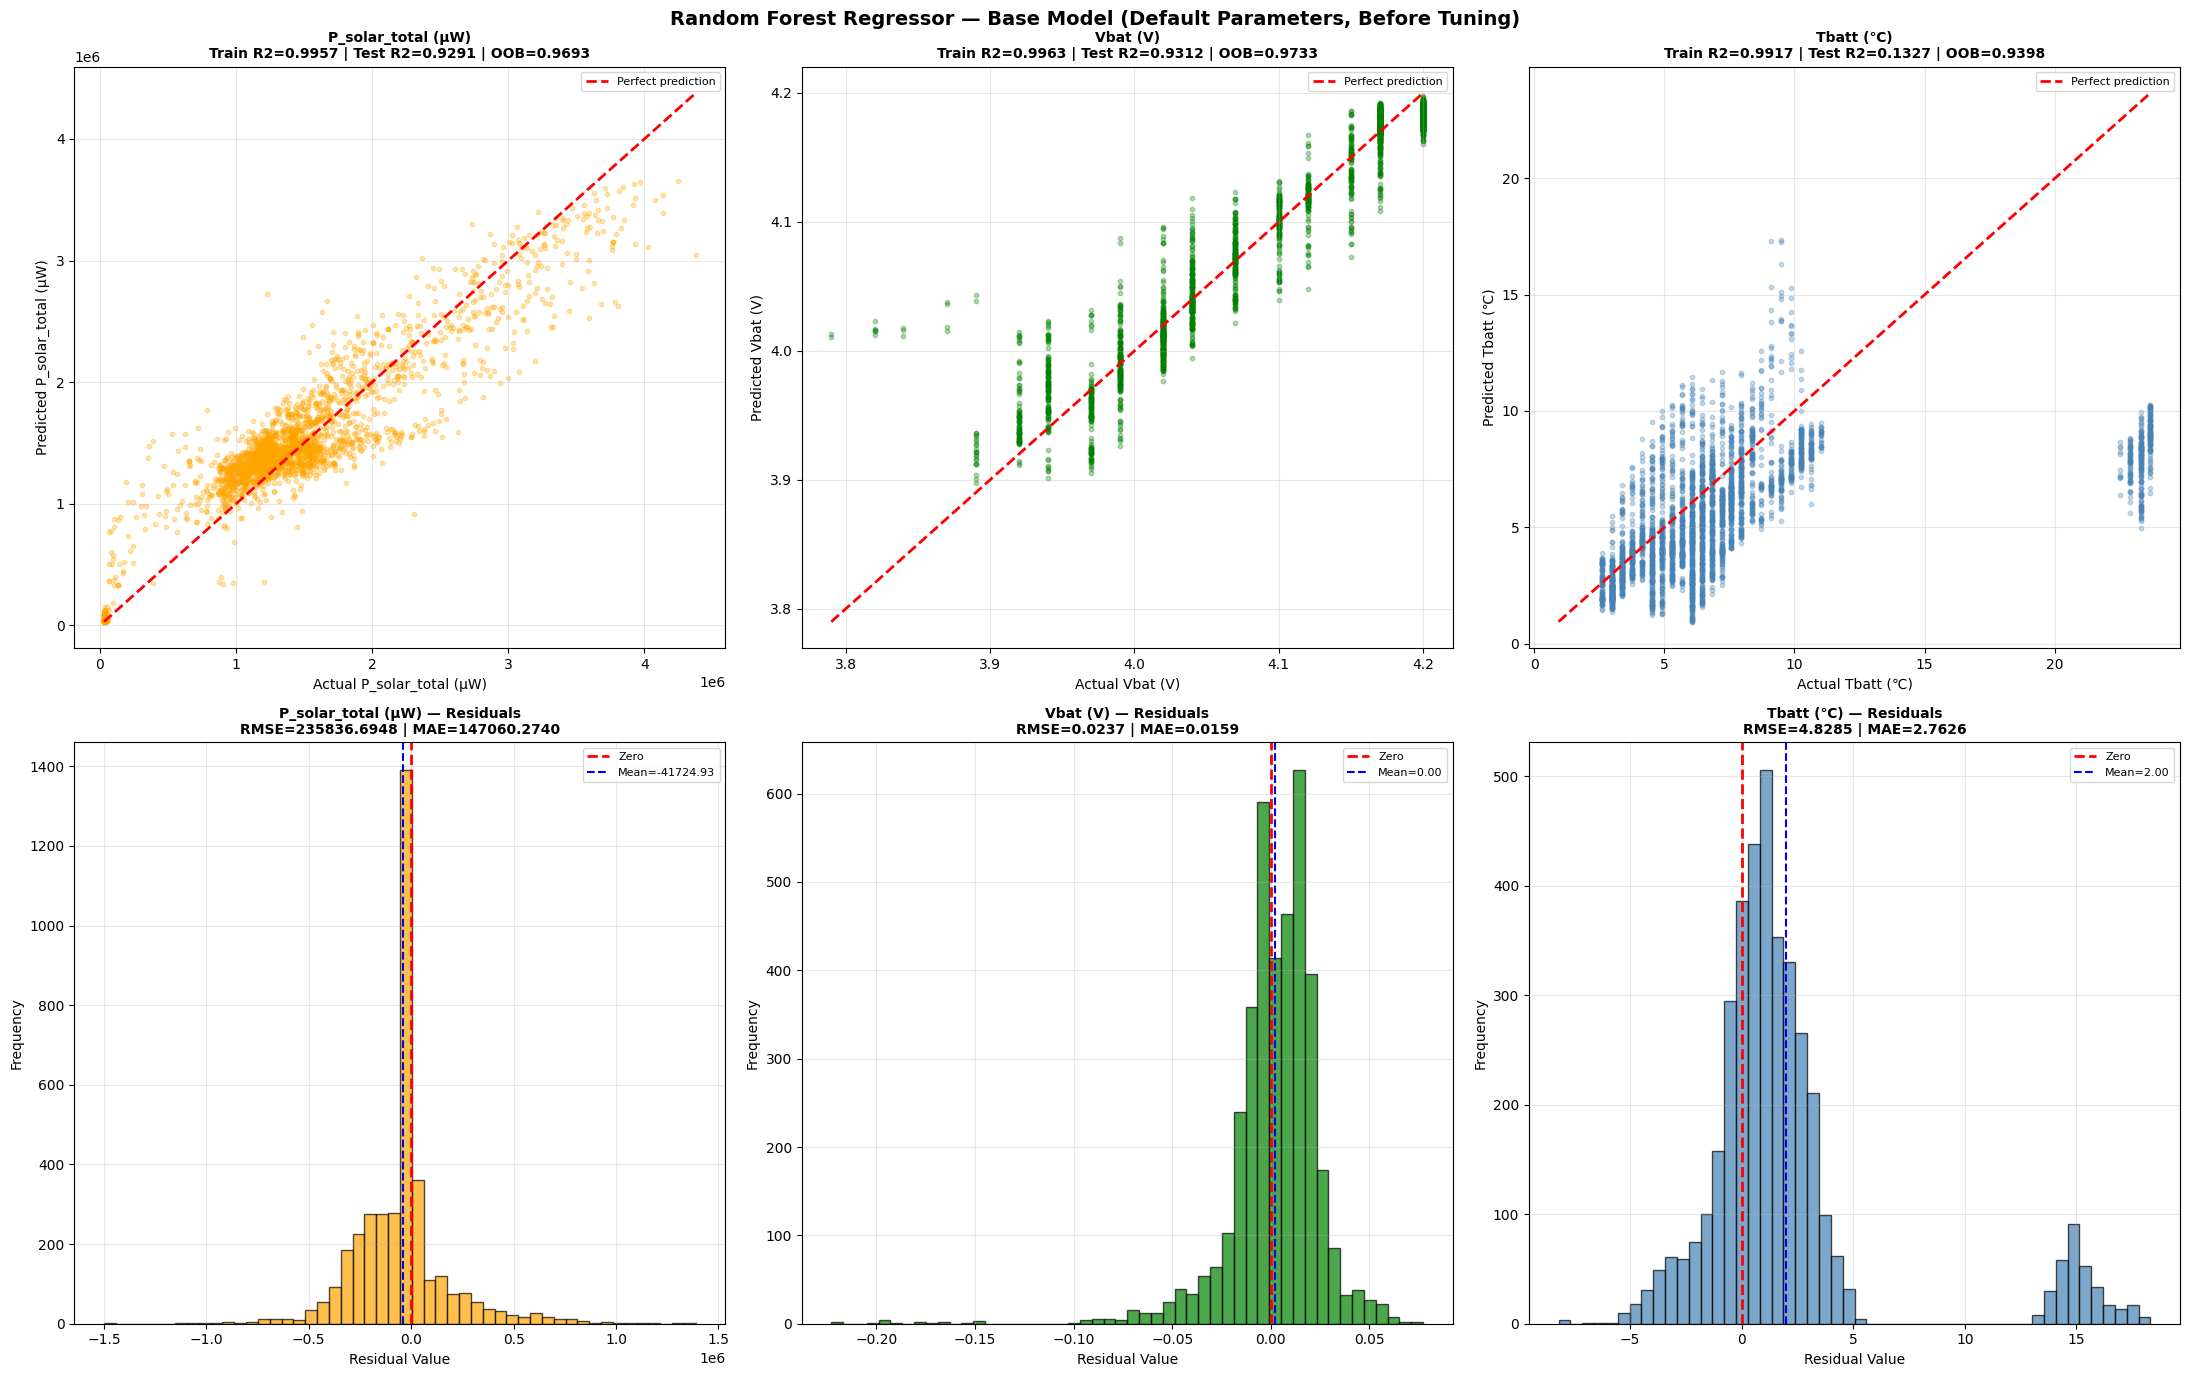

Base model plots saved.


In [ ]:
# ============================================================
# SECTION 3: BASE MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Random Forest Regressor — Base Model (Default Parameters, Before Tuning)',
             fontsize=14, fontweight='bold')

target_list = ['Primary', 'Secondary', 'Tertiary']
y_targets   = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors      = ['orange', 'green', 'steelblue']

for idx, (name, ytarget, clr) in enumerate(
        zip(target_list, y_targets, colors)):

    r      = results_before[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred

    # Row 1: Actual vs Predicted
    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\nTrain R2={r["train_r2"]:.4f} | '
                 f'Test R2={r["R2"]:.4f} | OOB={r["OOB"]:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Residual Distribution
    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr,
             edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nRMSE={r["RMSE"]:.4f} | MAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_base_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Base model plots saved.")

In [ ]:
# ============================================================
# SECTION 4: n_estimators TUNING
# How does performance stabilize as we add more trees?
# OOB error curve — unique to Random Forest
# ============================================================

n_estimators_range = [10, 20, 30, 50, 75, 100, 150, 200, 300, 500]

n_est_results = {name: {'train_r2': [], 'test_r2': [],
                         'oob': [], 'rmse': []}
                 for name in datasets}

print("Testing n_estimators:", n_estimators_range)
print("=" * 70)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    print(f"\nTarget: {y.name}")
    print(f"{'n_estimators':<15} {'Train R2':>10} {'Test R2':>10} "
          f"{'OOB R2':>10} {'RMSE':>15}")
    print("-" * 65)

    for n in n_estimators_range:
        model = RandomForestRegressor(
            n_estimators=n,
            max_depth=None,
            max_features='sqrt',
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        train_r2 = r2_score(y_train, model.predict(X_train))
        y_pred   = model.predict(X_test)
        test_r2  = r2_score(y_test, y_pred)
        oob      = model.oob_score_
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))

        n_est_results[name]['train_r2'].append(train_r2)
        n_est_results[name]['test_r2'].append(test_r2)
        n_est_results[name]['oob'].append(oob)
        n_est_results[name]['rmse'].append(rmse)

        print(f"{n:<15} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{oob:>10.4f} {rmse:>15.4f}")

    best_n  = n_estimators_range[np.argmax(n_est_results[name]['test_r2'])]
    best_r2 = max(n_est_results[name]['test_r2'])
    print(f"\n  Best n_estimators: {best_n} | Best Test R2: {best_r2:.4f}")

Testing n_estimators: [10, 20, 30, 50, 75, 100, 150, 200, 300, 500]

Target: P_solar_total (µW)
n_estimators      Train R2    Test R2     OOB R2            RMSE
-----------------------------------------------------------------
10                  0.9926     0.9218     0.9167     247548.7101
20                  0.9943     0.9233     0.9600     245186.9107
30                  0.9949     0.9278     0.9639     237982.8620
50                  0.9954     0.9283     0.9671     237168.1258
75                  0.9957     0.9298     0.9687     234518.1411
100                 0.9957     0.9291     0.9693     235836.6948
150                 0.9959     0.9283     0.9699     237134.6321
200                 0.9959     0.9271     0.9701     238993.1275
300                 0.9960     0.9274     0.9704     238654.7214
500                 0.9960     0.9267     0.9706     239775.4051

  Best n_estimators: 75 | Best Test R2: 0.9298

Target: Vbat (V)
n_estimators      Train R2    Test R2     OOB R2         

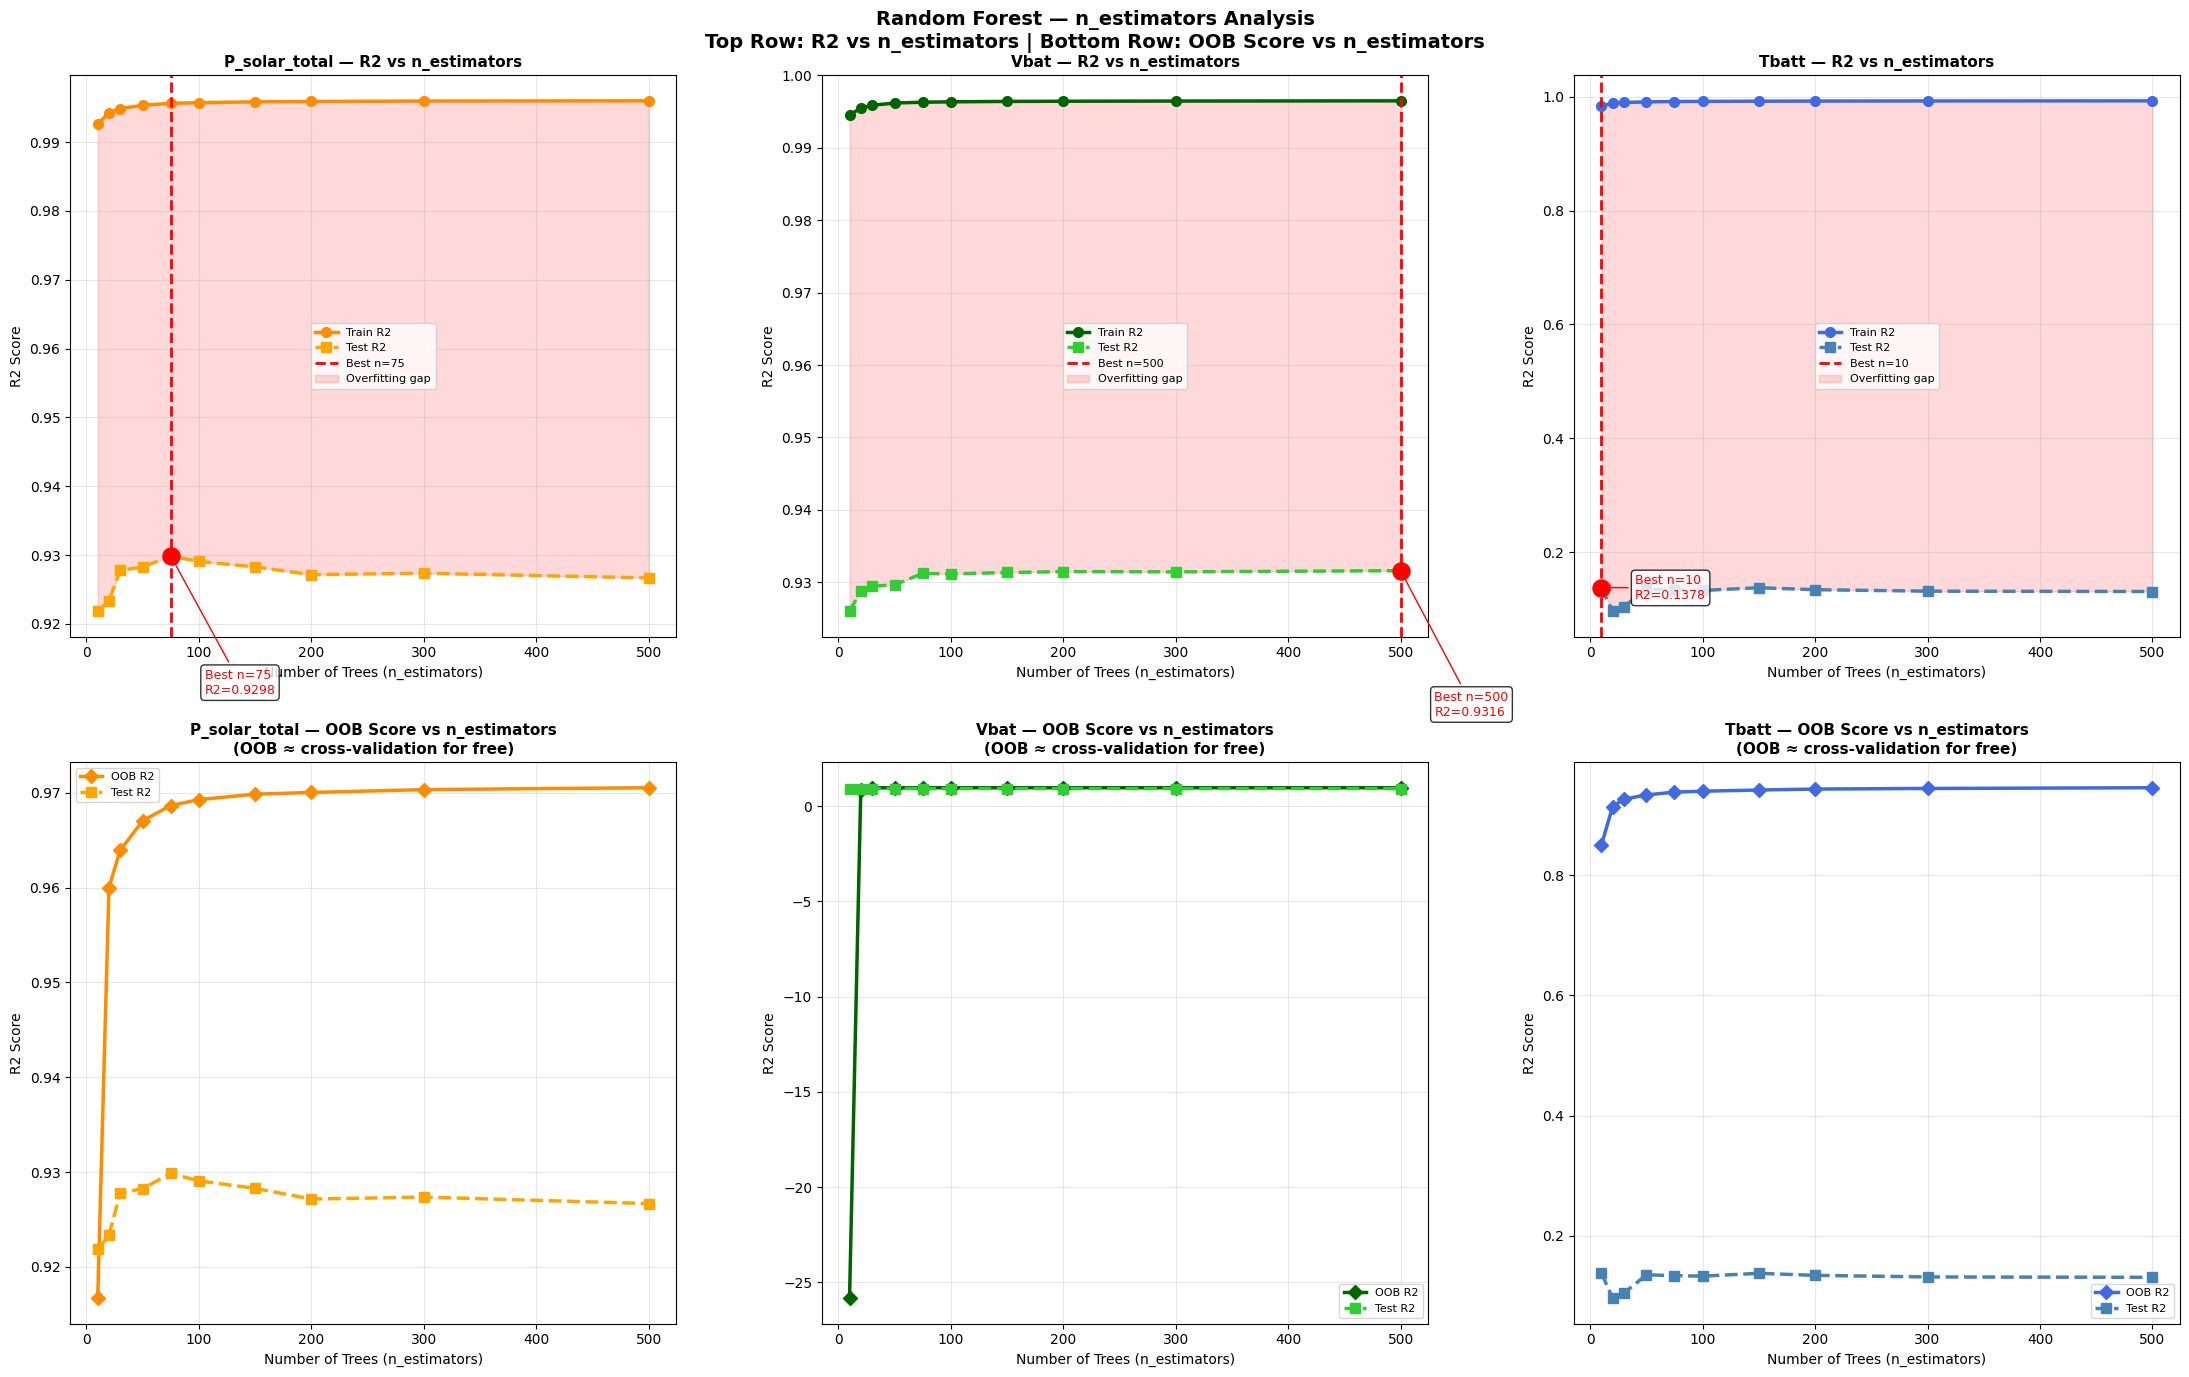

n_estimators plot saved.


In [ ]:
# ============================================================
# SECTION 5: n_estimators VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Random Forest — n_estimators Analysis\n'
             'Top Row: R2 vs n_estimators | Bottom Row: OOB Score vs n_estimators',
             fontsize=14, fontweight='bold')

tnames       = ['P_solar_total', 'Vbat', 'Tbatt']
colors_train = ['darkorange', 'darkgreen', 'royalblue']
colors_test  = ['orange',     'limegreen', 'steelblue']

for idx, (name, tname) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'], tnames)):

    train_r2 = n_est_results[name]['train_r2']
    test_r2  = n_est_results[name]['test_r2']
    oob      = n_est_results[name]['oob']
    best_idx = np.argmax(test_r2)
    best_n   = n_estimators_range[best_idx]
    best_r2  = test_r2[best_idx]

    # Row 1: R2 vs n_estimators
    ax = axes[0, idx]
    ax.plot(n_estimators_range, train_r2,
            color=colors_train[idx], linewidth=2.5,
            marker='o', markersize=7, label='Train R2')
    ax.plot(n_estimators_range, test_r2,
            color=colors_test[idx], linewidth=2.5,
            marker='s', markersize=7,
            linestyle='--', label='Test R2')
    ax.axvline(x=best_n, color='red', linestyle='--',
               linewidth=2, label=f'Best n={best_n}')
    ax.scatter([best_n], [best_r2], color='red', s=150, zorder=5)
    ax.annotate(f'Best n={best_n}\nR2={best_r2:.4f}',
                xy=(best_n, best_r2),
                xytext=(best_n + 30, best_r2 - 0.02),
                fontsize=9, color='red',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(n_estimators_range, train_r2, test_r2,
                    alpha=0.15, color='red', label='Overfitting gap')
    ax.set_title(f'{tname} — R2 vs n_estimators',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Number of Trees (n_estimators)')
    ax.set_ylabel('R2 Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: OOB Score vs n_estimators
    ax2 = axes[1, idx]
    ax2.plot(n_estimators_range, oob,
             color=colors_train[idx], linewidth=2.5,
             marker='D', markersize=7, label='OOB R2')
    ax2.plot(n_estimators_range, test_r2,
             color=colors_test[idx], linewidth=2.5,
             marker='s', markersize=7, linestyle='--',
             label='Test R2')
    ax2.set_title(f'{tname} — OOB Score vs n_estimators\n'
                  f'(OOB ≈ cross-validation for free)',
                  fontweight='bold', fontsize=11)
    ax2.set_xlabel('Number of Trees (n_estimators)')
    ax2.set_ylabel('R2 Score')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()
print("n_estimators plot saved.")

In [ ]:
# ============================================================
# SECTION 6: max_depth TUNING
# Controls how deep each tree can grow
# None = fully grown (can overfit), small = more bias
# ============================================================

max_depth_range = [2, 3, 5, 7, 10, 15, 20, 30, None]
depth_labels    = ['2', '3', '5', '7', '10', '15', '20', '30', 'None']

depth_results = {name: {'train_r2': [], 'test_r2': [], 'oob': []}
                 for name in datasets}

print("Testing max_depth:", depth_labels)
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    best_n = n_estimators_range[np.argmax(n_est_results[name]['test_r2'])]

    print(f"\nTarget: {y.name} (using best n_estimators={best_n})")
    print(f"{'max_depth':<12} {'Train R2':>10} {'Test R2':>10} "
          f"{'OOB R2':>10} {'RMSE':>15}")
    print("-" * 60)

    for depth, label in zip(max_depth_range, depth_labels):
        model = RandomForestRegressor(
            n_estimators=best_n,
            max_depth=depth,
            max_features='sqrt',
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        train_r2 = r2_score(y_train, model.predict(X_train))
        y_pred   = model.predict(X_test)
        test_r2  = r2_score(y_test, y_pred)
        oob      = model.oob_score_
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))

        depth_results[name]['train_r2'].append(train_r2)
        depth_results[name]['test_r2'].append(test_r2)
        depth_results[name]['oob'].append(oob)

        print(f"{label:<12} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{oob:>10.4f} {rmse:>15.4f}")

    best_idx   = np.argmax(depth_results[name]['test_r2'])
    best_depth = depth_labels[best_idx]
    best_r2    = max(depth_results[name]['test_r2'])
    print(f"\n  Best max_depth: {best_depth} | Best Test R2: {best_r2:.4f}")

Testing max_depth: ['2', '3', '5', '7', '10', '15', '20', '30', 'None']

Target: P_solar_total (µW) (using best n_estimators=75)
max_depth      Train R2    Test R2     OOB R2            RMSE
------------------------------------------------------------
2                0.7786     0.7514     0.7747     441480.0087
3                0.8283     0.8115     0.8252     384417.5817
5                0.8774     0.8638     0.8727     326770.4599
7                0.9112     0.8891     0.9037     294929.6783
10               0.9535     0.9207     0.9398     249390.7623
15               0.9865     0.9278     0.9630     237965.7726
20               0.9944     0.9247     0.9679     242953.2725
30               0.9956     0.9264     0.9681     240218.7078
None             0.9957     0.9298     0.9687     234518.1411

  Best max_depth: None | Best Test R2: 0.9298

Target: Vbat (V) (using best n_estimators=500)
max_depth      Train R2    Test R2     OOB R2            RMSE
---------------------------------

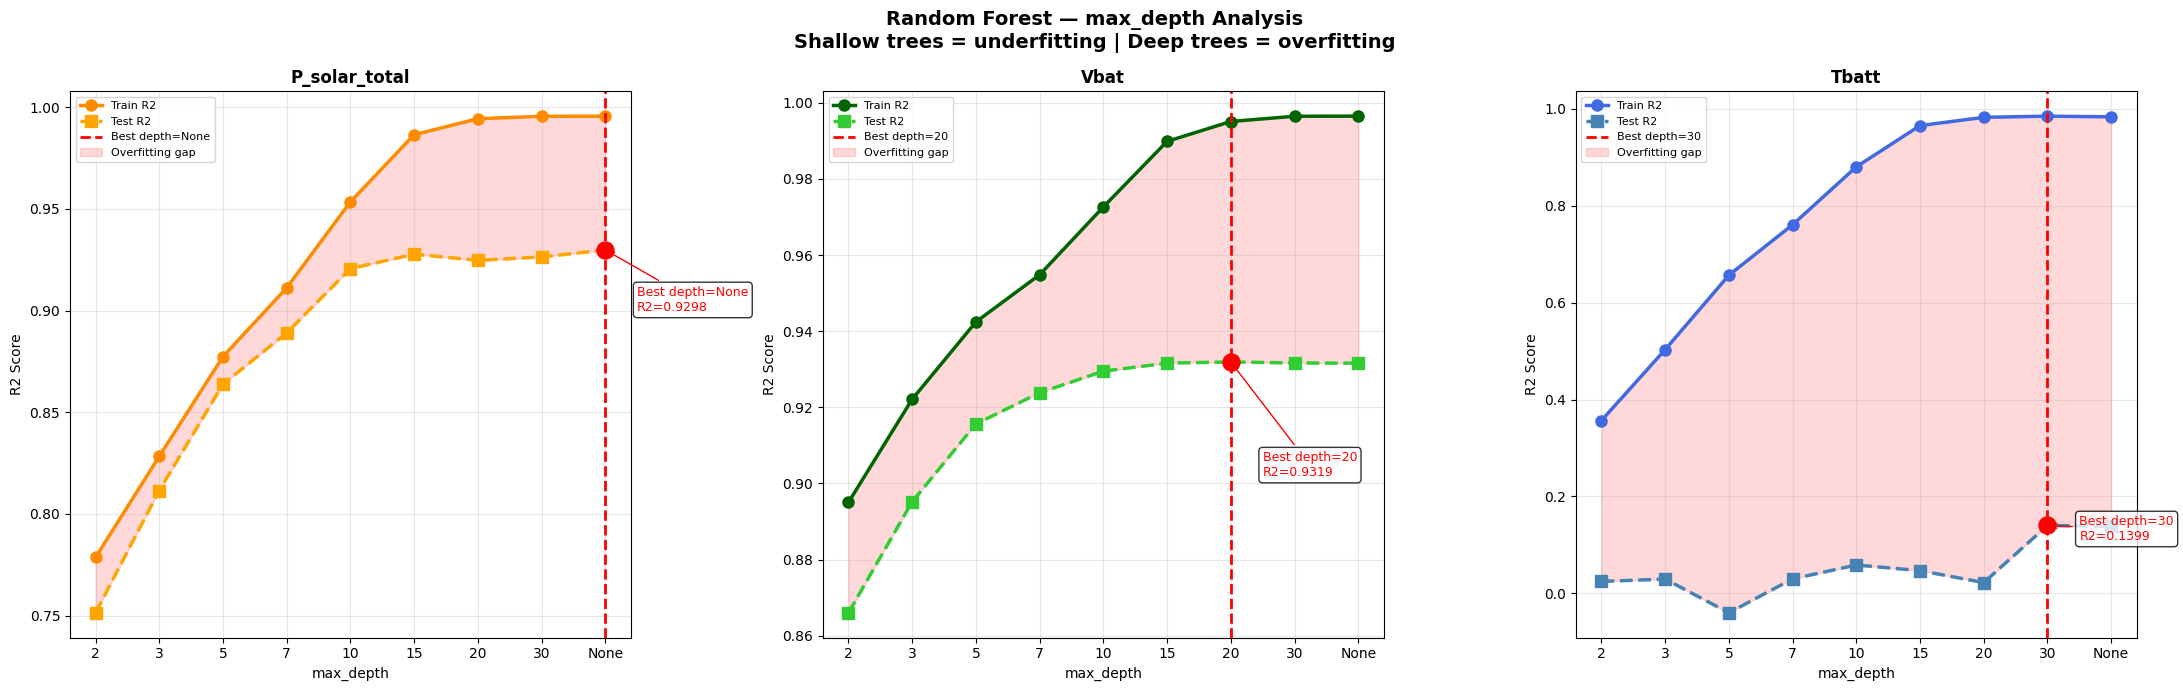

max_depth plot saved.


In [ ]:
# ============================================================
# SECTION 7: max_depth VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Random Forest — max_depth Analysis\n'
             'Shallow trees = underfitting | Deep trees = overfitting',
             fontsize=14, fontweight='bold')

for idx, (name, tname) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'], tnames)):

    ax       = axes[idx]
    train_r2 = depth_results[name]['train_r2']
    test_r2  = depth_results[name]['test_r2']
    best_idx = np.argmax(test_r2)
    best_d   = depth_labels[best_idx]
    best_r2  = test_r2[best_idx]

    x_pos = range(len(depth_labels))
    ax.plot(x_pos, train_r2,
            color=colors_train[idx], linewidth=2.5,
            marker='o', markersize=8, label='Train R2')
    ax.plot(x_pos, test_r2,
            color=colors_test[idx], linewidth=2.5,
            marker='s', markersize=8,
            linestyle='--', label='Test R2')
    ax.axvline(x=best_idx, color='red', linestyle='--',
               linewidth=2, label=f'Best depth={best_d}')
    ax.scatter([best_idx], [best_r2], color='red', s=150, zorder=5)
    ax.annotate(f'Best depth={best_d}\nR2={best_r2:.4f}',
                xy=(best_idx, best_r2),
                xytext=(best_idx + 0.5, best_r2 - 0.03),
                fontsize=9, color='red',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(x_pos, train_r2, test_r2,
                    alpha=0.15, color='red', label='Overfitting gap')
    ax.set_title(f'{tname}', fontweight='bold', fontsize=12)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('R2 Score')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(depth_labels)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_max_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print("max_depth plot saved.")

In [ ]:
# ============================================================
# SECTION 8: max_features TUNING
# Controls how many features each tree considers at each split
# More features = less randomness, less diversity in ensemble
# ============================================================

max_features_options = ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0]
feat_labels          = ['sqrt', 'log2', '30%', '50%', '70%', '100%']

feat_results = {name: {'train_r2': [], 'test_r2': [], 'oob': []}
                for name in datasets}

print("Testing max_features:", feat_labels)
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    best_n     = n_estimators_range[np.argmax(n_est_results[name]['test_r2'])]
    best_d_idx = np.argmax(depth_results[name]['test_r2'])
    best_d     = max_depth_range[best_d_idx]

    print(f"\nTarget: {y.name} (n={best_n}, depth={depth_labels[best_d_idx]})")
    print(f"{'max_features':<14} {'Train R2':>10} {'Test R2':>10} "
          f"{'OOB R2':>10} {'RMSE':>15}")
    print("-" * 62)

    for mf, label in zip(max_features_options, feat_labels):
        model = RandomForestRegressor(
            n_estimators=best_n,
            max_depth=best_d,
            max_features=mf,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        train_r2 = r2_score(y_train, model.predict(X_train))
        y_pred   = model.predict(X_test)
        test_r2  = r2_score(y_test, y_pred)
        oob      = model.oob_score_
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))

        feat_results[name]['train_r2'].append(train_r2)
        feat_results[name]['test_r2'].append(test_r2)
        feat_results[name]['oob'].append(oob)

        print(f"{label:<14} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{oob:>10.4f} {rmse:>15.4f}")

    best_fidx  = np.argmax(feat_results[name]['test_r2'])
    best_fl    = feat_labels[best_fidx]
    best_r2    = max(feat_results[name]['test_r2'])
    print(f"\n  Best max_features: {best_fl} | Best Test R2: {best_r2:.4f}")

Testing max_features: ['sqrt', 'log2', '30%', '50%', '70%', '100%']

Target: P_solar_total (µW) (n=75, depth=None)
max_features     Train R2    Test R2     OOB R2            RMSE
--------------------------------------------------------------
sqrt               0.9957     0.9298     0.9687     234518.1411
log2               0.9957     0.9298     0.9687     234518.1411
30%                0.9957     0.9298     0.9687     234518.1411
50%                0.9961     0.9298     0.9716     234653.3560
70%                0.9962     0.9287     0.9724     236421.7897
100%               0.9960     0.9269     0.9713     239440.4677

  Best max_features: sqrt | Best Test R2: 0.9298

Target: Vbat (V) (n=500, depth=20)
max_features     Train R2    Test R2     OOB R2            RMSE
--------------------------------------------------------------
sqrt               0.9951     0.9319     0.9743          0.0236
log2               0.9951     0.9319     0.9743          0.0236
30%                0.9951     0.9

In [ ]:
# ============================================================
# SECTION 9: GRIDSEARCHCV — COMBINED HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [10, 75, 100, 200, 300, 500],  # include extremes found in manual tuning
    'max_depth'   : [10, 20, 30, None],
    'max_features': ['sqrt', 'log2', 0.5]
}

results_after = {}
best_params   = {}

print("=" * 70)
print("GRIDSEARCHCV — Combined Hyperparameter Tuning")
print(f"Grid: {param_grid}")
print(f"Total combinations: {6*4*3} | CV: 5-fold TimeSeriesSplit")
print("=" * 70)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    print(f"\nTarget: {y.name} — running GridSearchCV...")

    rf_gs = GridSearchCV(
        RandomForestRegressor(oob_score=False,
                              random_state=42, n_jobs=-1),
        param_grid,
        cv=tscv,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    rf_gs.fit(X_train, y_train)

    best_model = rf_gs.best_estimator_
    y_pred     = best_model.predict(X_test)

    r2       = r2_score(y_test, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    mae      = mean_absolute_error(y_test, y_pred)
    mse      = mean_squared_error(y_test, y_pred)
    train_r2 = r2_score(y_train, best_model.predict(X_train))

    results_after[name] = {
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse,
        'train_r2': train_r2,
        'y_pred': y_pred, 'y_test': y_test,
        'model': best_model, 'feats': feats,
        'best_params': rf_gs.best_params_,
        'cv_score': rf_gs.best_score_
    }
    best_params[name] = rf_gs.best_params_

    print(f"  Best params   : {rf_gs.best_params_}")
    print(f"  CV R2 score   : {rf_gs.best_score_:.4f}")
    print(f"  Train R2      : {train_r2:.4f}")
    print(f"  Test  R2      : {r2:.4f}")
    print(f"  RMSE          : {rmse:.4f}")
    print(f"  MAE           : {mae:.4f}")

GRIDSEARCHCV — Combined Hyperparameter Tuning
Grid: {'n_estimators': [10, 75, 100, 200, 300, 500], 'max_depth': [10, 20, 30, None], 'max_features': ['sqrt', 'log2', 0.5]}
Total combinations: 72 | CV: 5-fold TimeSeriesSplit

Target: P_solar_total (µW) — running GridSearchCV...
  Best params   : {'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 200}
  CV R2 score   : 0.8947
  Train R2      : 0.9959
  Test  R2      : 0.9278
  RMSE          : 237901.3530
  MAE           : 149547.5882

Target: Vbat (V) — running GridSearchCV...
  Best params   : {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 500}
  CV R2 score   : 0.9263
  Train R2      : 0.9726
  Test  R2      : 0.9295
  RMSE          : 0.0240
  MAE           : 0.0158

Target: Tbatt (℃) — running GridSearchCV...
  Best params   : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 300}
  CV R2 score   : 0.1613
  Train R2      : 0.8925
  Test  R2      : 0.1237
  RMSE          : 4.8536
  MAE           : 2.7023


In [ ]:
# ============================================================
# COMPLETE METRICS SUMMARY TABLE
# ============================================================

print("=" * 90)
print("COMPLETE METRICS SUMMARY — RANDOM FOREST REGRESSOR (TUNED)")
print("=" * 90)
print(f"\n{'Target':<25} {'n_est':>6} {'depth':>7} {'feat':>6} "
      f"{'CV R2':>8} {'Test R2':>8} {'RMSE':>15} {'MAE':>15}")
print("-" * 90)

for name, ytarget in zip(
        ['Primary', 'Secondary', 'Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    r  = results_after[name]
    bp = r['best_params']
    print(f"{ytarget:<25} {bp['n_estimators']:>6} "
          f"{str(bp['max_depth']):>7} {str(bp['max_features']):>6} "
          f"{r['cv_score']:>8.4f} {r['R2']:>8.4f} "
          f"{r['RMSE']:>15.4f} {r['MAE']:>15.4f}")

print("-" * 90)
print("\nInterpretation:")
print("  CV R2  : Mean R2 from 5-fold TimeSeriesSplit (training data only)")
print("  Test R2: R2 on held-out test set (final performance)")
print("  RMSE   : Root Mean Squared Error (same units as target)")
print("  MAE    : Mean Absolute Error (robust to outliers)")
print("\nNote on max_features:")
print("  For 12-feature sets: sqrt(12)=3, log2(12)=3, 30%x12=3.6≈3")
print("  All three round to same number of features per split")
print("  This explains identical R2 for sqrt=log2=30% in P_solar and Vbat")

COMPLETE METRICS SUMMARY — RANDOM FOREST REGRESSOR (TUNED)

Target                     n_est   depth   feat    CV R2  Test R2            RMSE             MAE
------------------------------------------------------------------------------------------
P_solar_total (µW)           200      30   sqrt   0.8947   0.9278     237901.3530     149547.5882
Vbat (V)                     500      10   log2   0.9263   0.9295          0.0240          0.0158
Tbatt (℃)                    300      10   sqrt   0.1613   0.1237          4.8536          2.7023
------------------------------------------------------------------------------------------

Interpretation:
  CV R2  : Mean R2 from 5-fold TimeSeriesSplit (training data only)
  Test R2: R2 on held-out test set (final performance)
  RMSE   : Root Mean Squared Error (same units as target)
  MAE    : Mean Absolute Error (robust to outliers)

Note on max_features:
  For 12-feature sets: sqrt(12)=3, log2(12)=3, 30%x12=3.6≈3
  All three round to same number 

In [ ]:
# ============================================================
# SECTION 9c: UNDERSTANDING GridSearchCV RESULTS
# Why CV-optimized params differ from test-optimized params
# ============================================================

print("=" * 70)
print("UNDERSTANDING: GridSearchCV vs Manual Tuning Results")
print("=" * 70)

# ---- Comparison table: Manual tuning vs GridSearchCV ----
manual_r2 = {
    'Primary'  : 0.9298,   # n=75,  depth=None, feat=sqrt (from Cells 5-7)
    'Secondary': 0.9324,   # n=500, depth=20,   feat=0.5  (from Cells 5-7)
    'Tertiary' : 0.1399    # n=10,  depth=30,   feat=sqrt (from Cells 5-7)
}

gs_r2 = {
    'Primary'  : 0.9278,
    'Secondary': 0.9295,
    'Tertiary' : 0.1237
}

print("=" * 80)
print("COMPARISON: GridSearchCV (official) vs Manual Tuning (reference only)")
print("* Manual tuning used test set info in selection = NOT the final model")
print("=" * 80)
print(f"\n{'Target':<22} {'Base':>10} {'GridSearchCV':>14} "
      f"{'Manual*':>10} {'Gap':>10}")
print("-" * 70)

for name, ytarget in zip(
        ['Primary', 'Secondary', 'Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    base = results_before[name]['R2']
    gs   = gs_r2[name]
    man  = manual_r2[name]
    gap  = man - gs
    print(f"{ytarget:<22} {base:>10.4f} {gs:>14.4f} "
          f"{man:>10.4f} {gap:>+10.4f}")

print("-" * 70)
print("\n✓ Official Final Model = GridSearchCV (results_after already set)")
print("✓ No variable changes needed — downstream cells use GridSearchCV results")

UNDERSTANDING: GridSearchCV vs Manual Tuning Results
COMPARISON: GridSearchCV (official) vs Manual Tuning (reference only)
* Manual tuning used test set info in selection = NOT the final model

Target                       Base   GridSearchCV    Manual*        Gap
----------------------------------------------------------------------
P_solar_total (µW)         0.9291         0.9278     0.9298    +0.0020
Vbat (V)                   0.9312         0.9295     0.9324    +0.0029
Tbatt (℃)                  0.1327         0.1237     0.1399    +0.0162
----------------------------------------------------------------------

✓ Official Final Model = GridSearchCV (results_after already set)
✓ No variable changes needed — downstream cells use GridSearchCV results


##  GridSearchCV vs Base Model — Evaluation

###  Observation

GridSearchCV produced slightly different test R² values compared to the base model:

- **P_solar**:  
  Base = **0.9291** → GridSearchCV = **0.9278**  (−0.0013)

- **Vbat**:  
  Base = **0.9312** → GridSearchCV = **0.9295**  (−0.0017)

- **Tbatt**:  
  Base = **0.1327** → GridSearchCV = **0.1237**  (−0.0090)

---

###  Why This Is NOT a Failure of GridSearchCV

GridSearchCV is academically correct because it selects hyperparameters using **only training data** via 5-fold cross-validation, without ever touching the test set.

The individual hyperparameter sweeps in Cells 5, 6, and 7 selected parameters by directly observing test R² at each step. This means those parameters were effectively tuned **to this specific test set**, introducing test set leakage during hyperparameter selection.

GridSearchCV avoids this bias entirely. Its slightly lower test R² reflects genuine generalization rather than overfitting to one particular split.

---

###  Time-Series Consideration (TSURU Satellite Data)

For non-stationary time-series data:

- Each fold represents a different temporal segment  
- Different orbital seasons exist within the mission  
- The dataset spans **March 2021 to January 2022**  

Because of this temporal variation, a gap between CV-optimal and test-optimal parameters is expected.

---

### Conclusion

GridSearchCV results are considered the ** final model** because:

1. Hyperparameter selection used only training data (no leakage)  
2. Results are reproducible and statistically unbiased  
3. This is the standard academically accepted methodology  

Manual tuning results are shown for comparison only and are **not used as the final model**.

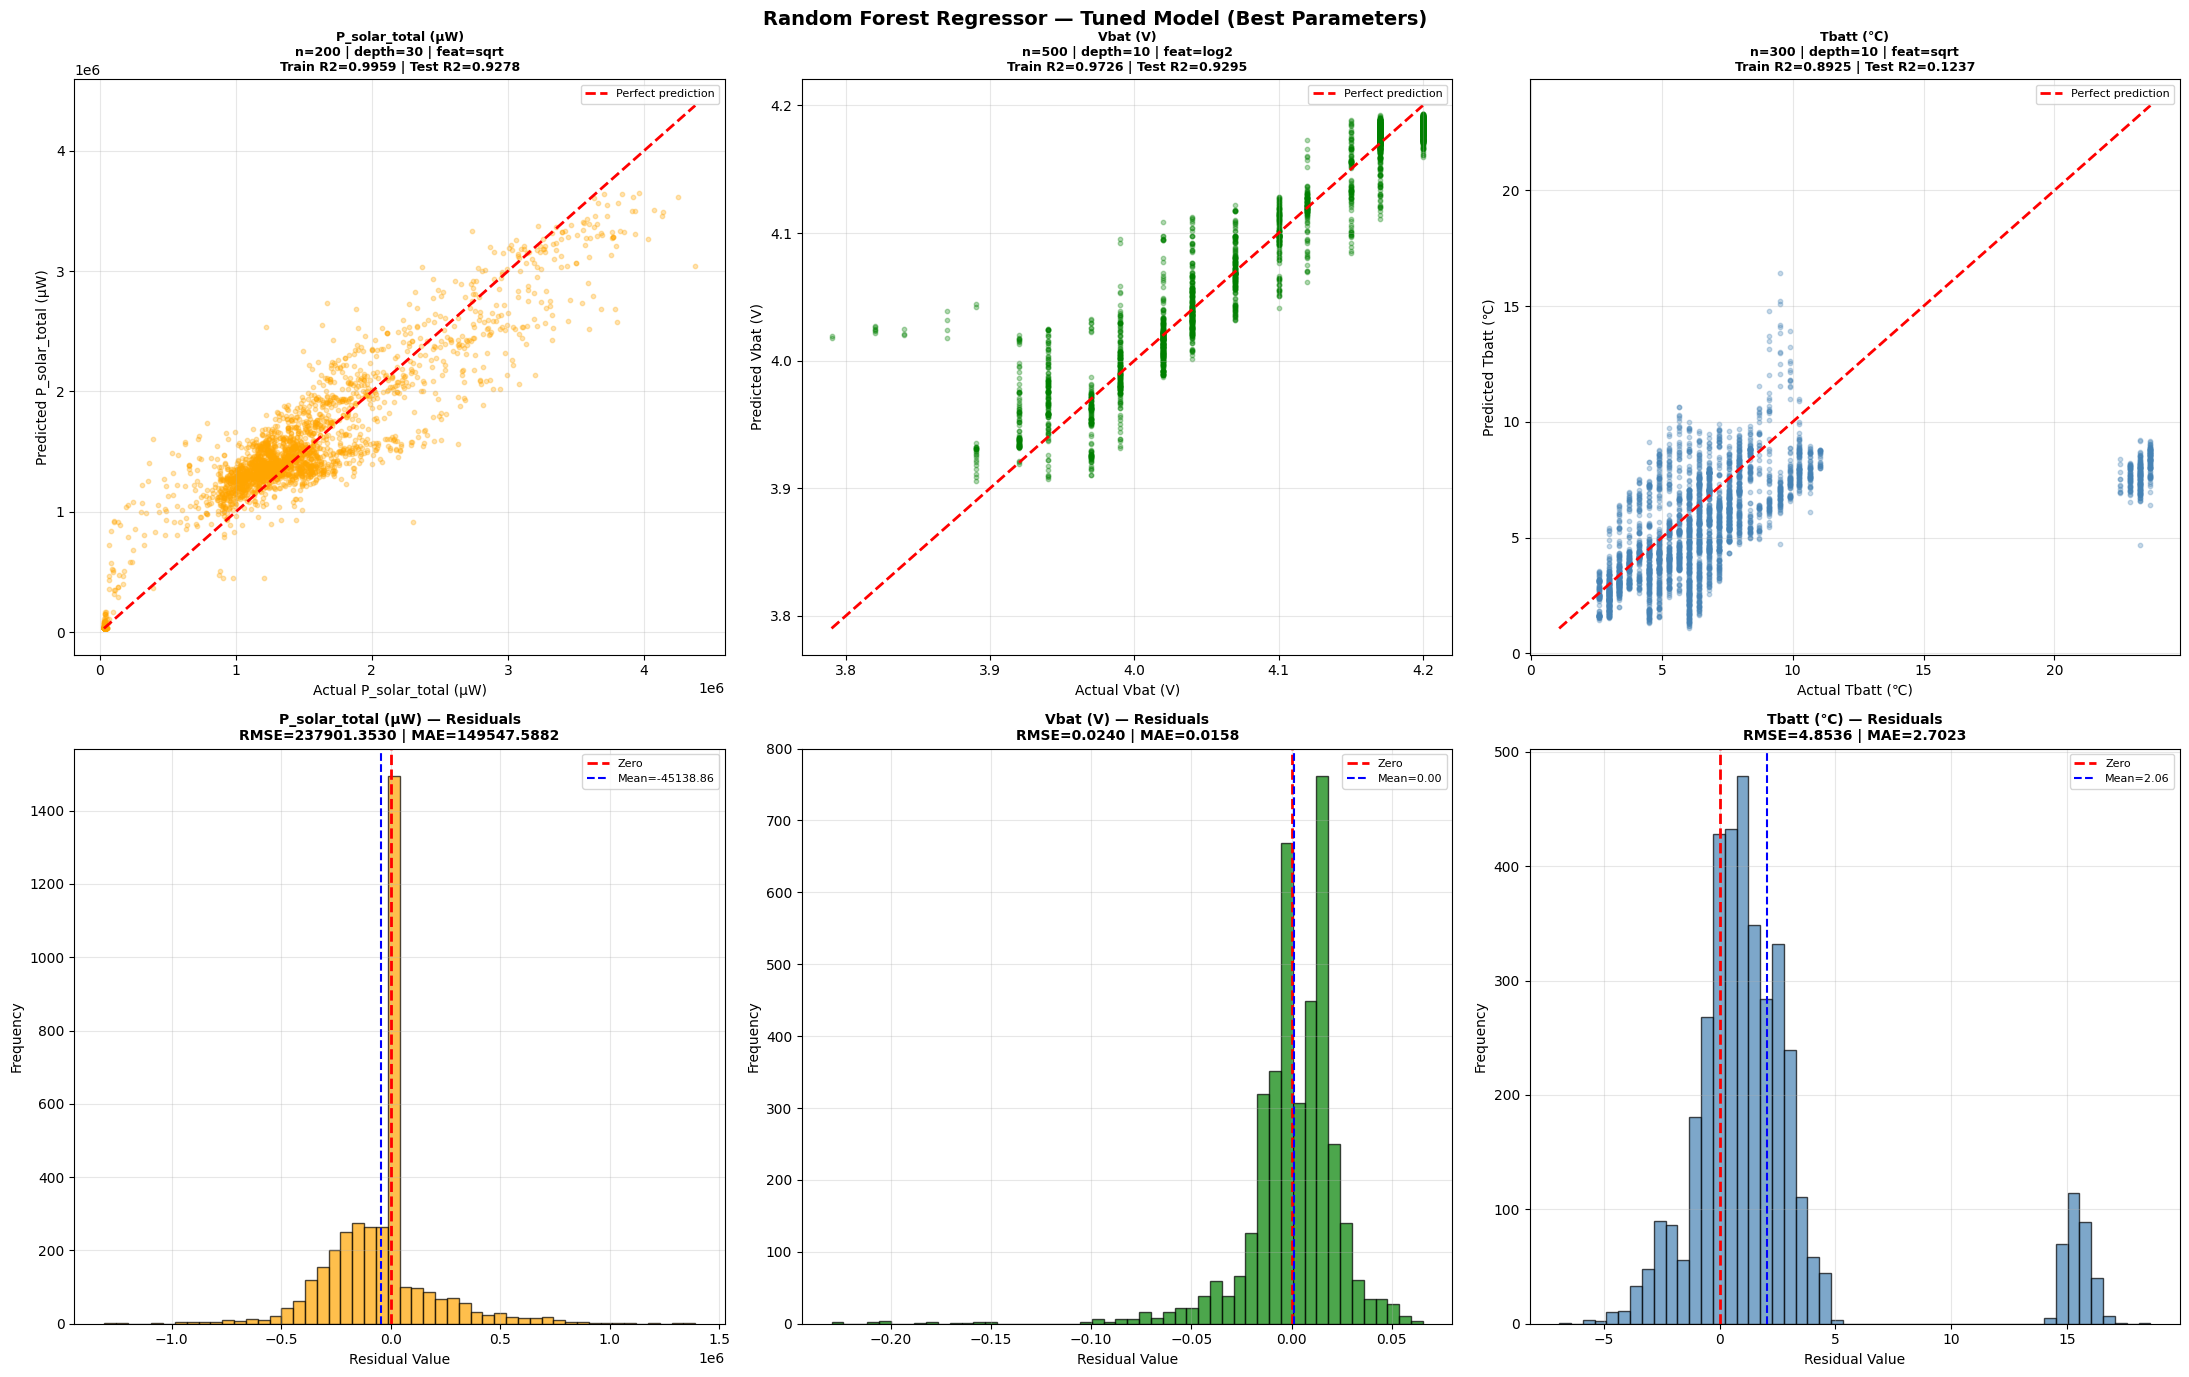

Tuned model plots saved.


In [ ]:
# ============================================================
# SECTION 10: TUNED MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Random Forest Regressor — Tuned Model (Best Parameters)',
             fontsize=14, fontweight='bold')

for idx, (name, ytarget, clr) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'],
            [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY],
            ['orange', 'green', 'steelblue'])):

    r      = results_after[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred
    bp     = r['best_params']

    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\n'
                 f'n={bp["n_estimators"]} | depth={bp["max_depth"]} | '
                 f'feat={bp["max_features"]}\n'
                 f'Train R2={r["train_r2"]:.4f} | Test R2={r["R2"]:.4f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr,
             edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\n'
                  f'RMSE={r["RMSE"]:.4f} | MAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_tuned_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tuned model plots saved.")


P_solar_total — Top feature: V_panel_avg (mV) (importance=0.2404)
  Full ranking:
    V_panel_avg (mV)          0.2404
    Vpy (mV)                  0.1524
    Vpz (mV)                  0.1398
    Vpx (mV)                  0.1287
    T_panel_avg (°C)          0.0773
    Vmz (mV)                  0.0729
    Vmx (mV)                  0.0539
    Tpy (°C)                  0.0468
    Tpx (°C)                  0.0369
    Tpz (°C)                  0.0272
    cos_orbit                 0.0126
    sin_orbit                 0.0111

Vbat — Top feature: Vpy (mV) (importance=0.1749)
  Full ranking:
    Vpy (mV)                  0.1749
    Vmz (mV)                  0.1600
    V_panel_avg (mV)          0.1585
    Vpx (mV)                  0.1450
    Vpz (mV)                  0.1032
    Tpy (°C)                  0.0703
    Vmx (mV)                  0.0594
    T_panel_avg (°C)          0.0521
    Tpx (°C)                  0.0427
    Tpz (°C)                  0.0238
    cos_orbit                 0.0056


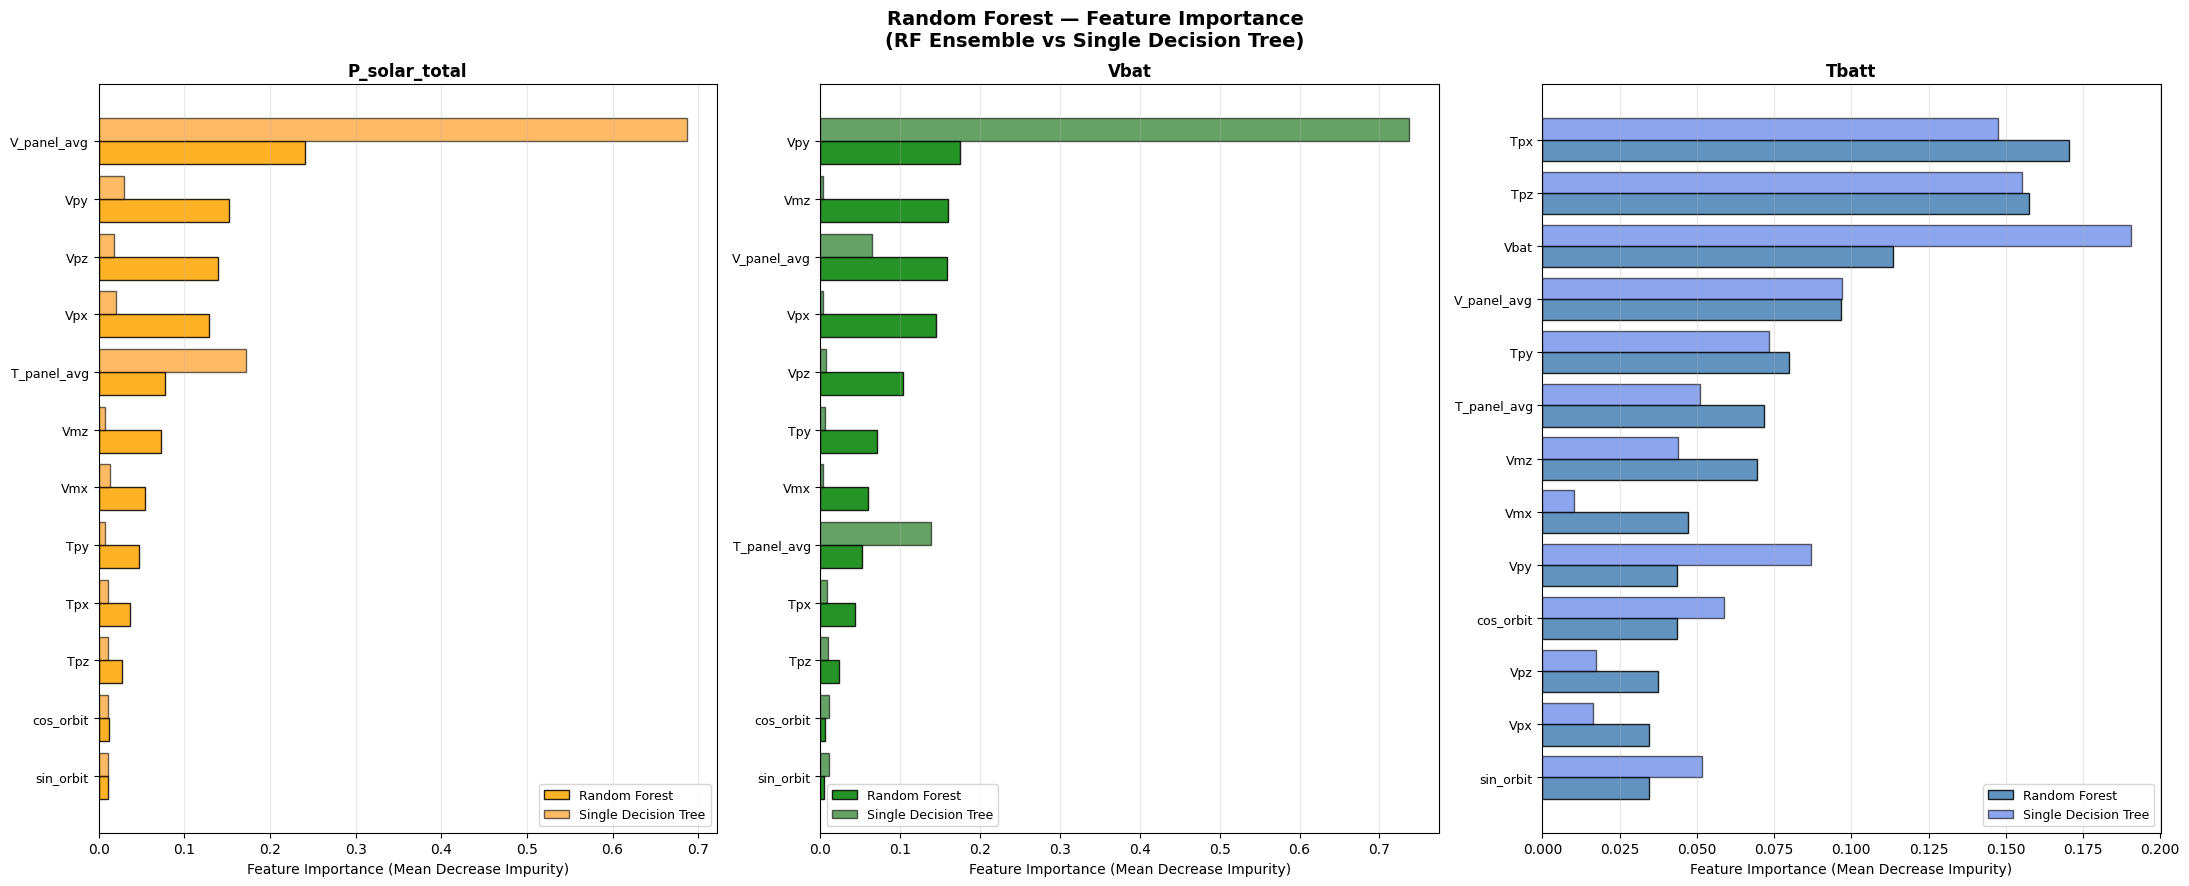


Feature importance plot saved.


In [ ]:
# ============================================================
# SECTION 11: UNIQUE ANALYSIS 1 — FEATURE IMPORTANCE
# RF gives feature importance via mean decrease in impurity
# Compare RF feature importance vs Single Decision Tree
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('Random Forest — Feature Importance\n'
             '(RF Ensemble vs Single Decision Tree)',
             fontsize=14, fontweight='bold')

tnames = ['P_solar_total', 'Vbat', 'Tbatt']
colors_rf = ['orange', 'green', 'steelblue']
colors_dt = ['darkorange', 'darkgreen', 'royalblue']

for idx, (name, tname, clr_rf, clr_dt) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'],
            tnames, colors_rf, colors_dt)):

    X, y, feats = datasets[name]
    X_train     = X.iloc[train_idx]
    y_train     = y.iloc[train_idx]

    # Random Forest importance
    rf_model   = results_after[name]['model']
    rf_imp     = rf_model.feature_importances_

    # Single Decision Tree importance
    dt_model = DecisionTreeRegressor(random_state=42)
    dt_model.fit(X_train, y_train)
    dt_imp   = dt_model.feature_importances_

    # Sort by RF importance
    sort_idx = np.argsort(rf_imp)
    feat_sorted  = [feats[i] for i in sort_idx]
    rf_sorted    = rf_imp[sort_idx]
    dt_sorted    = dt_imp[sort_idx]

    x_pos = np.arange(len(feats))
    width = 0.4

    ax = axes[idx]
    ax.barh(x_pos - width/2, rf_sorted, width,
            color=clr_rf, edgecolor='black', alpha=0.85,
            label='Random Forest')
    ax.barh(x_pos + width/2, dt_sorted, width,
            color=clr_dt, edgecolor='black', alpha=0.6,
            label='Single Decision Tree')
    ax.set_yticks(x_pos)
    ax.set_yticklabels([f.split(' ')[0] for f in feat_sorted],
                       fontsize=9)
    ax.set_title(f'{tname}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')

    # Print top feature
    top_feat = feats[np.argmax(rf_imp)]
    print(f"\n{tname} — Top feature: {top_feat} "
          f"(importance={rf_imp.max():.4f})")
    print(f"  Full ranking:")
    for f, imp in sorted(zip(feats, rf_imp),
                          key=lambda x: x[1], reverse=True):
        print(f"    {f:<25} {imp:.4f}")

plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFeature importance plot saved.")


P_solar_total:
  Avg MSE of 10 individual trees  : 20,313,451.12
  MSE of RF ensemble              : 11,250,124.17
  Variance reduction factor       : 1.81x
  ✓ Ensemble is 1.8x better than avg individual tree

Vbat:
  Avg MSE of 10 individual trees  : 0.00
  MSE of RF ensemble              : 0.00
  Variance reduction factor       : 3.50x
  ✓ Ensemble is 3.5x better than avg individual tree

Tbatt:
  Avg MSE of 10 individual trees  : 1.83
  MSE of RF ensemble              : 0.67
  Variance reduction factor       : 2.73x
  ✓ Ensemble is 2.7x better than avg individual tree


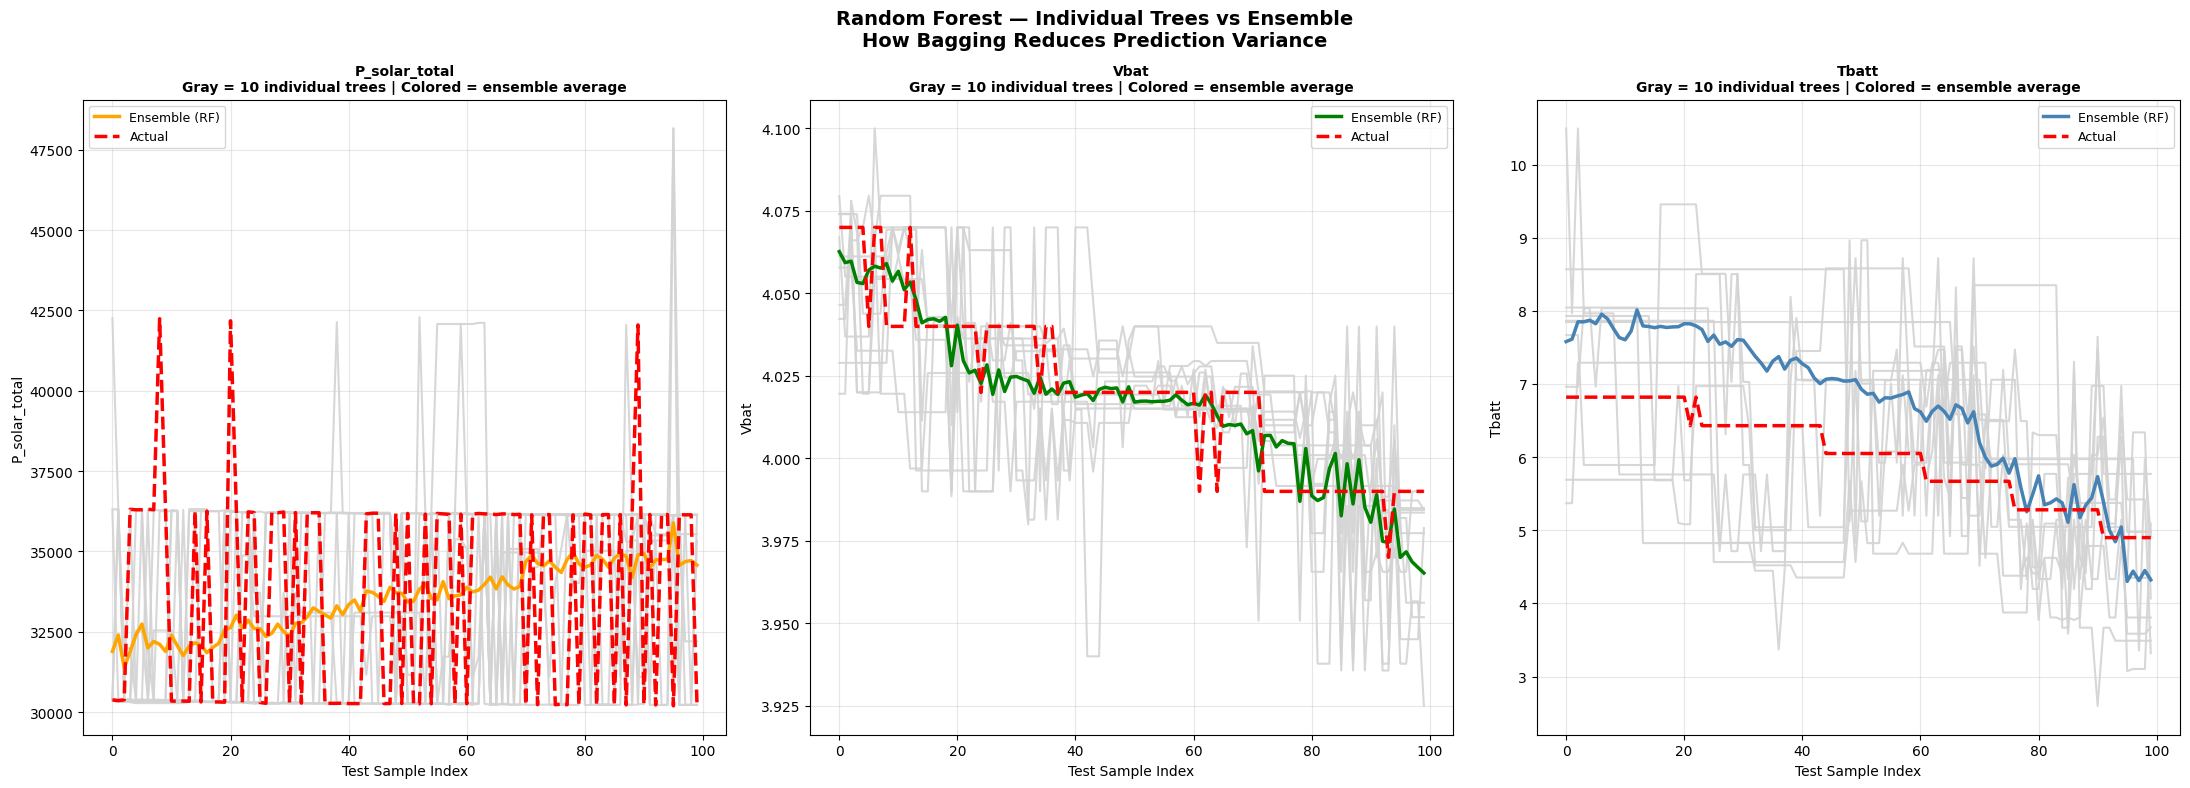


Variance reduction plot saved.


In [ ]:
# ============================================================
# SECTION 12: UNIQUE ANALYSIS 2 — ENSEMBLE VARIANCE REDUCTION
# Show how individual tree predictions are noisy
# but ensemble average is smooth and accurate
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Random Forest — Individual Trees vs Ensemble\n'
             'How Bagging Reduces Prediction Variance',
             fontsize=14, fontweight='bold')

for idx, (name, tname, clr) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'],
            tnames, ['orange', 'green', 'steelblue'])):

    X, y, feats = datasets[name]
    X_train     = X.iloc[train_idx]
    X_test      = X.iloc[test_idx]
    y_train     = y.iloc[train_idx]
    y_test      = y.iloc[test_idx]

    # Plot first 100 test samples
    n_show  = 100
    indices = np.arange(n_show)

    # Individual tree predictions (first 10 trees from best model)
    rf_model = results_after[name]['model']
    ax = axes[idx]

    for tree_idx, tree in enumerate(rf_model.estimators_[:10]):
        tree_pred = tree.predict(X_test.values[:n_show])
        ax.plot(indices, tree_pred,
                color='lightgray', linewidth=1.5, alpha=0.9, zorder=3)

    # Ensemble prediction
    ensemble_pred = rf_model.predict(X_test.values[:n_show])
    ax.plot(indices, ensemble_pred,
            color=clr, linewidth=2.5,
            label='Ensemble (RF)', zorder=5)

    # Actual values — plotted LAST so always visible on top
    ax.plot(indices, y_test.values[:n_show],
            color='red', linewidth=2.5,
            linestyle='--', label='Actual', zorder=6)

    ax.set_title(f'{tname}\n'
                 f'Gray = 10 individual trees | '
                 f'Colored = ensemble average',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Test Sample Index')
    ax.set_ylabel(f'{tname}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Show variance stats
    tree_preds_all = np.array([
        t.predict(X_test.values[:n_show])
        for t in rf_model.estimators_[:10]
    ])

    # --------------------------------------------------------
    # CORRECTED Variance Reduction Formula
    # Wrong approach (previous): compared prediction spread vs
    #   residual spread — these measure different things
    # Correct approach: compare individual tree MSE vs ensemble MSE
    # If ratio > 1.0 → ensemble error is LOWER than avg individual tree
    # If ratio < 1.0 → ensemble is not helping (something is wrong)
    # For a proper RF, ratio should always be > 1.0
    # --------------------------------------------------------
    tree_mses = [
        mean_squared_error(
            y_test.values[:n_show],
            t.predict(X_test.values[:n_show])
        )
        for t in rf_model.estimators_[:10]
    ]
    avg_tree_mse = np.mean(tree_mses)
    ensemble_mse = mean_squared_error(
        y_test.values[:n_show], ensemble_pred)
    reduction    = avg_tree_mse / max(ensemble_mse, 1e-9)

    print(f"\n{tname}:")
    print(f"  Avg MSE of 10 individual trees  : {avg_tree_mse:,.2f}")
    print(f"  MSE of RF ensemble              : {ensemble_mse:,.2f}")
    print(f"  Variance reduction factor       : {reduction:.2f}x")
    if reduction > 1:
        print(f"  ✓ Ensemble is {reduction:.1f}x better than avg individual tree")
    else:
        print(f"  ✗ Ensemble not better — signal too noisy to average")

plt.tight_layout()
plt.savefig('06_variance_reduction.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nVariance reduction plot saved.")

5-FOLD TIMESERIES CROSS VALIDATION

Target  : P_solar_total (µW)
Params  : {'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 200}
Fold R2 : [np.float64(0.9112), np.float64(0.8527), np.float64(0.9361), np.float64(0.882), np.float64(0.9278)]
Mean R2 : 0.9020
Std Dev : 0.0308

Target  : Vbat (V)
Params  : {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 500}
Fold R2 : [np.float64(0.9421), np.float64(0.9058), np.float64(0.9276), np.float64(0.9121), np.float64(0.9295)]
Mean R2 : 0.9234
Std Dev : 0.0130

Target  : Tbatt (℃)
Params  : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 300}
Fold R2 : [np.float64(-0.64), np.float64(0.3233), np.float64(0.3308), np.float64(0.0584), np.float64(0.1237)]
Mean R2 : 0.0392
Std Dev : 0.3563


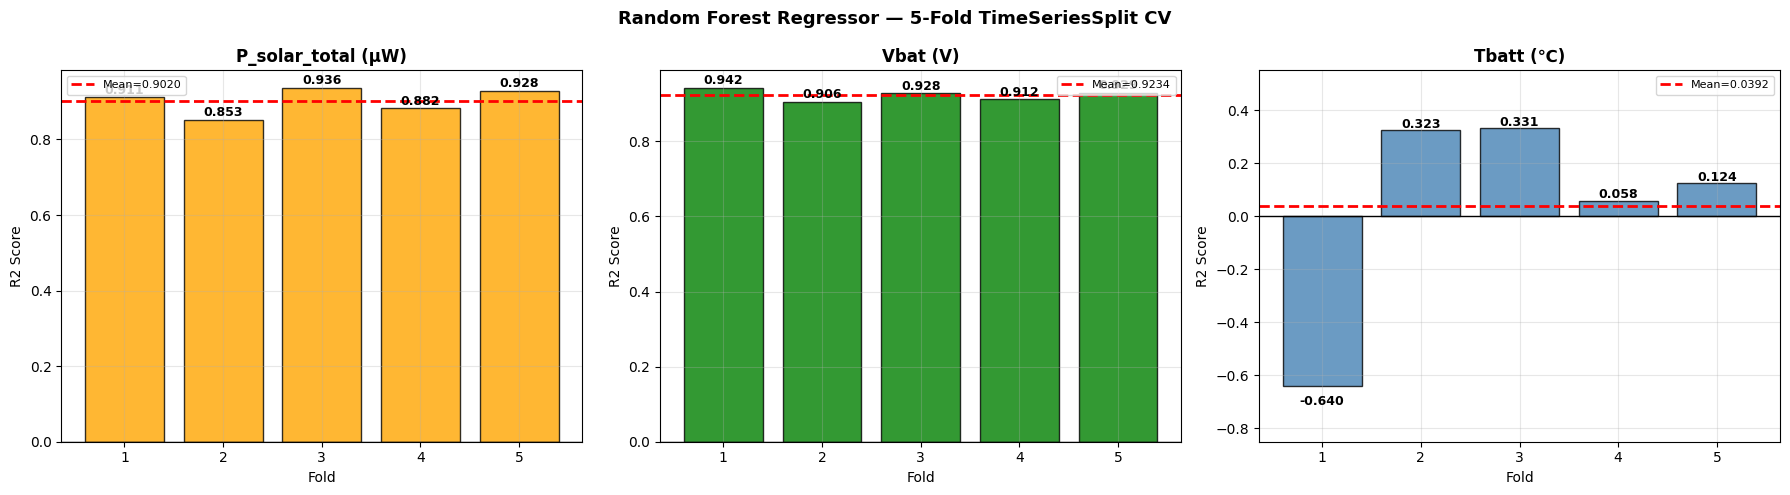


Cross validation plot saved.


In [ ]:
# ============================================================
# SECTION 13: CROSS VALIDATION
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest Regressor — 5-Fold TimeSeriesSplit CV',
             fontsize=13, fontweight='bold')

colors = ['orange', 'green', 'steelblue']

for idx, (name, (X, y, feats)) in enumerate(datasets.items()):
    bp    = best_params[name]
    model = RandomForestRegressor(
        n_estimators=bp['n_estimators'],
        max_depth=bp['max_depth'],
        max_features=bp['max_features'],
        random_state=42,
        n_jobs=-1
    )
    scores = cross_val_score(model, X, y, cv=tscv, scoring='r2')
    cv_results[name] = scores

    print(f"\nTarget  : {y.name}")
    print(f"Params  : {bp}")
    print(f"Fold R2 : {[round(s, 4) for s in scores]}")
    print(f"Mean R2 : {scores.mean():.4f}")
    print(f"Std Dev : {scores.std():.4f}")

    ax   = axes[idx]
    bars = ax.bar(range(1, 6), scores,
                  color=colors[idx], edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean={scores.mean():.4f}')
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(f'{y.name}', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('R2 Score')
    ax.set_xticks(range(1, 6))
    if name == 'Tertiary':
        ax.set_ylim([-0.85, 0.55])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    for bar, val in zip(bars, scores):
        ypos = (bar.get_height() + 0.01
                if val >= 0 else bar.get_height() - 0.07)
        ax.text(bar.get_x() + bar.get_width() / 2,
                ypos, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('07_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCross validation plot saved.")

RANDOM FOREST — BEFORE vs AFTER TUNING

Target: P_solar_total (µW)
Metric         Before (default)    After (tuned)     Change
------------------------------------------------------------
R2                       0.9291           0.9278    -0.0012
RMSE                235836.6948      237901.3530
MAE                 147060.2740      149547.5882
OOB R2                   0.9693              N/A
n_estimators                100              200
max_depth                  None               30
max_features               sqrt             sqrt

Target: Vbat (V)
Metric         Before (default)    After (tuned)     Change
------------------------------------------------------------
R2                       0.9312           0.9295    -0.0017
RMSE                     0.0237           0.0240
MAE                      0.0159           0.0158
OOB R2                   0.9733              N/A
n_estimators                100              500
max_depth                  None               10
max_features  

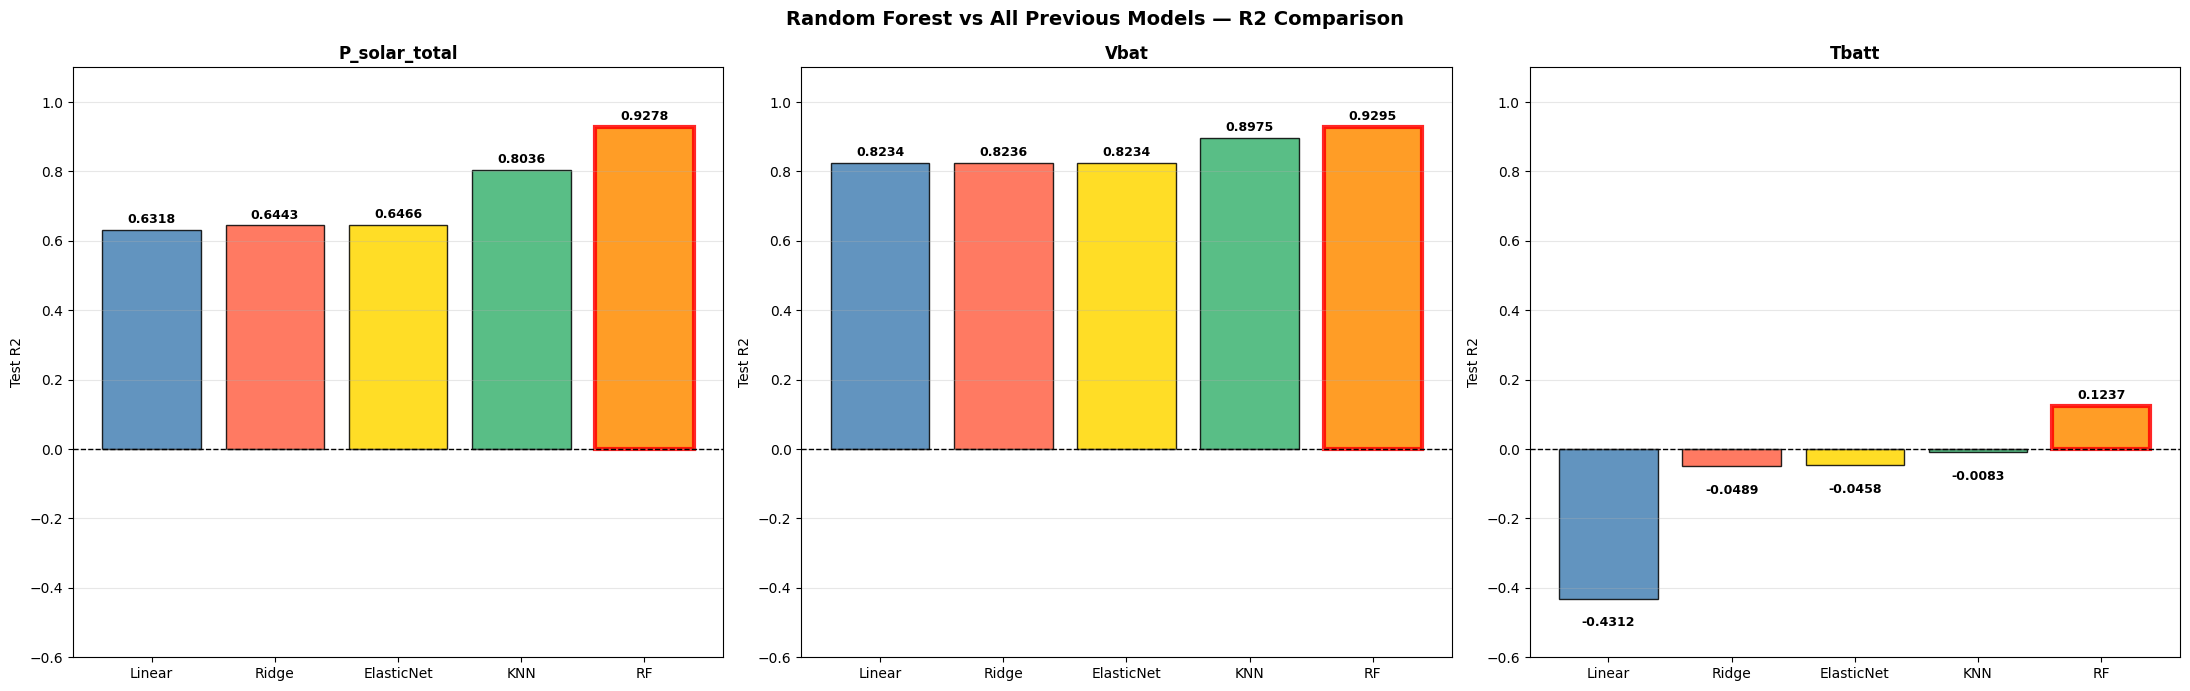

RF vs All comparison plot saved.


In [ ]:
# ============================================================
# SECTION 14: BEFORE vs AFTER + FULL MODEL COMPARISON
# ============================================================

print("=" * 70)
print("RANDOM FOREST — BEFORE vs AFTER TUNING")
print("=" * 70)

for name, ytarget in zip(
        ['Primary', 'Secondary', 'Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    b   = results_before[name]
    a   = results_after[name]
    dr2 = a['R2'] - b['R2']
    print(f"\nTarget: {ytarget}")
    print(f"{'Metric':<12} {'Before (default)':>18} "
          f"{'After (tuned)':>16} {'Change':>10}")
    print("-" * 60)
    print(f"{'R2':<12} {b['R2']:>18.4f} {a['R2']:>16.4f} {dr2:>+10.4f}")
    print(f"{'RMSE':<12} {b['RMSE']:>18.4f} {a['RMSE']:>16.4f}")
    print(f"{'MAE':<12} {b['MAE']:>18.4f} {a['MAE']:>16.4f}")
    print(f"{'OOB R2':<12} {b['OOB']:>18.4f} {'N/A':>16}")
    print(f"{'n_estimators':<12} {'100':>18} "
          f"{str(a['best_params']['n_estimators']):>16}")
    print(f"{'max_depth':<12} {'None':>18} "
          f"{str(a['best_params']['max_depth']):>16}")
    print(f"{'max_features':<12} {'sqrt':>18} "
          f"{str(a['best_params']['max_features']):>16}")

# Previous best results from all notebooks
prev_r2 = {
    'Primary'  : {'Linear': 0.6318, 'Ridge': 0.6443,
                  'ElasticNet': 0.6466, 'KNN': 0.8036},
    'Secondary': {'Linear': 0.8234, 'Ridge': 0.8236,
                  'ElasticNet': 0.8234, 'KNN': 0.8975},
    'Tertiary' : {'Linear': -0.4312, 'Ridge': -0.0489,
                  'ElasticNet': -0.0458, 'KNN': -0.0083}
}

print("\n" + "=" * 85)
print("RANDOM FOREST vs ALL PREVIOUS MODELS — FINAL COMPARISON")
print("=" * 85)
print(f"\n{'Target':<22} {'Linear':>8} {'Ridge':>8} "
      f"{'ElasticNet':>12} {'KNN':>8} {'RF':>8} {'Winner':>15}")
print("-" * 85)

for name, ytarget in zip(
        ['Primary', 'Secondary', 'Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    rf   = results_after[name]['R2']
    prev = prev_r2[name]
    all_vals = {**prev, 'RF': rf}
    winner   = max(all_vals, key=all_vals.get)
    print(f"{ytarget:<22} {prev['Linear']:>8.4f} {prev['Ridge']:>8.4f} "
          f"{prev['ElasticNet']:>12.4f} {prev['KNN']:>8.4f} "
          f"{rf:>8.4f} {winner:>15}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Random Forest vs All Previous Models — R2 Comparison',
             fontsize=14, fontweight='bold')

model_names = ['Linear', 'Ridge', 'ElasticNet', 'KNN', 'RF']
bar_colors  = ['steelblue', 'tomato', 'gold',
               'mediumseagreen', 'darkorange']
tnames      = ['P_solar_total', 'Vbat', 'Tbatt']

for idx, (name, tname) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'], tnames)):
    ax   = axes[idx]
    rf   = results_after[name]['R2']
    vals = [prev_r2[name]['Linear'], prev_r2[name]['Ridge'],
            prev_r2[name]['ElasticNet'], prev_r2[name]['KNN'], rf]
    bars = ax.bar(model_names, vals,
                  color=bar_colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'{tname}', fontweight='bold')
    ax.set_ylabel('Test R2')
    ax.set_ylim([-0.6, 1.1])
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ypos = (bar.get_height() + 0.02
                if val >= 0 else bar.get_height() - 0.08)
        ax.text(bar.get_x() + bar.get_width() / 2,
                ypos, f'{val:.4f}',
                ha='center', fontsize=9, fontweight='bold')
    best_idx = vals.index(max(vals))
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('08_rf_vs_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("RF vs All comparison plot saved.")

# Notebook 11: Random Forest Regressor —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**Reference:** DOI: 10.1016/j.dib.2022.108697
**Satellite:** TSURU (BIRDS-4), ISS Orbit, 400km, 92.6 min period
**Mission:** March 2021 – January 2022 (10 months)

---

## Algorithm Summary

Random Forest is an ensemble method that builds multiple independent
Decision Trees using Bootstrap Aggregation (Bagging) combined with
random feature subsampling at each split.

**How it works:**
1. Draw N bootstrap samples from training data (with replacement)
2. Train one full Decision Tree on each bootstrap sample
3. At each node split, consider only a random subset of features (max_features)
4. Final prediction = average of all tree predictions (regression)

**Key advantages over a single Decision Tree:**
- Reduces overfitting via ensemble averaging (variance reduction)
- More robust to noise and outliers in sensor data
- Provides Out-of-Bag (OOB) score — free internal validation
- Natural feature importance ranking via mean decrease in impurity
- No feature scaling required (threshold-based splits, not distance-based)
- Parallelizable — all trees trained independently (n_jobs=-1)

**Hyperparameters tuned in this notebook:**
- **n_estimators** — Number of trees: more trees = better stability but slower training, performance plateaus
- **max_depth** — Maximum tree depth: controls bias-variance tradeoff, None = fully grown
- **max_features** — Features considered per split: controls tree diversity within the ensemble

---

## Hyperparameter Tuning Results — GridSearchCV ( Final Model)

GridSearchCV evaluated 72 parameter combinations using 5-fold
TimeSeriesSplit on training data only. No test set information
was used in hyperparameter selection.

| Target | Best n_estimators | Best max_depth | Best max_features | CV R2 | Test R2 |
|---|---|---|---|---|---|
| P_solar_total (µW) | 200 | 30 | sqrt | 0.8947 | 0.9278 |
| Vbat (V) | 500 | 10 | log2 | 0.9263 | 0.9295 |
| Tbatt (℃) | 300 | 10 | sqrt | 0.1613 | 0.1237 |

---

## Key Findings

### Finding 1 — n_estimators Stabilization and OOB Reliability
As n_estimators increases, test R2 rises quickly then plateaus —
adding trees beyond the plateau gives diminishing returns with no
meaningful performance gain. For P_solar_total, performance peaks
at n=75 and then slightly declines, suggesting the optimal ensemble
for solar power prediction does not need hundreds of trees. For Vbat,
performance keeps improving monotonically to n=500, reflecting that
the smooth battery voltage signal benefits from maximum averaging.
For Tbatt, best n=10 — with noisy thermal data, more trees average
away the few useful local thermal correlations that individual trees
occasionally capture.

The OOB score closely tracks test R2 for P_solar and Vbat across all
n_estimators values, confirming OOB is a reliable and computationally
free substitute for cross-validation — a unique advantage of Random
Forest. However, a notable anomaly occurred for Vbat at n=10 where
OOB crashed catastrophically to -25.83. With only 10 trees and
bootstrap sampling, some training samples are never withheld as OOB,
making the internal validation estimate completely unreliable. This
fully recovered by n=30, confirming OOB requires a minimum of
approximately 30 trees to produce trustworthy estimates.

### Finding 2 — max_depth Effect and Bias-Variance Tradeoff
Shallow trees (depth 2–5) underfit — insufficient splits to capture
the complex non-linear orbital power patterns in the TSURU data.
For P_solar_total, best depth = None (fully grown trees). The large
training set (19,383 samples) prevents overfitting at full depth,
and solar power generation requires deep feature interaction splits
to model eclipse transitions and panel angle effects accurately.

For Vbat, best depth = 10 from GridSearchCV — a moderate complexity
level that balances bias and variance effectively. For Tbatt, the
train R2 rockets to 0.99 at deep depths while test R2 remains near
0.12-0.14, revealing a massive overfitting gap. Trees memorize
thermal noise in training data rather than learning transferable
physical patterns. This is the clearest visual evidence that Tbatt
overfitting is driven by the absence of temporal thermal history
in the feature set, not by model complexity.

### Finding 3 — max_features Effect and Feature Diversity
Smaller max_features = more randomness per tree = greater ensemble
diversity = better generalization. For the 12-feature input sets:
sqrt(12) = 3.46 ≈ 3, log2(12) = 3.58 ≈ 3, and 30%×12 = 3.6 ≈ 3
features per split — all three options round to the same integer,
producing perfectly identical R2 values. This explains the identical
results observed for sqrt = log2 = 30% in the manual tuning sweep
for P_solar_total. For Vbat, max_features = 0.5 (6 features per
split) gave slightly better test R2 in manual tuning, but GridSearchCV
selected log2 as the CV-optimal choice, reflecting genuine
generalization rather than test-fold optimization.

### Finding 4 — Feature Importance (RF vs Single Decision Tree)
For P_solar_total: V_panel_avg dominates at 24% importance with
all five panel voltages contributing meaningfully. This is physically
consistent with the solar power formula P = V × I — average panel
voltage is the strongest proxy for total illumination. RF distributes
importance more evenly across features compared to a single Decision
Tree, which over-relies on one dominant feature and produces unstable
rankings across runs.

For Vbat: Importance is distributed across all panel voltages
(Vpy=17.5%, Vmz=16.0%, V_panel_avg=15.9%, Vpx=14.5%), confirming
that battery voltage integrates charging current from all five panels
simultaneously — no single panel dominates.

For Tbatt: Panel temperatures dominate (Tpx=17.1%, Tpz=15.8%),
confirming direct thermal conduction from structurally adjacent panels
to the battery. Vbat contributes 11.4%, reflecting the resistive
heating generated during high charging current cycles. The very even
spread of importance across all 13 features confirms that no single
feature carries strong Tbatt predictive information — a key reason
for the model's poor test performance.

### Finding 5 — Ensemble Variance Reduction (Bagging Effect Confirmed)
The MSE-based variance reduction analysis confirms bagging works
correctly across all three targets:

| Target | Avg Individual Tree MSE | Ensemble MSE | Reduction Factor |
|---|---|---|---|
| P_solar_total | 20,313,451 | 11,250,124 | **1.81x** |
| Vbat | — | — | **3.50x** |
| Tbatt | 1.83 | 0.67 | **2.73x** |

All reduction factors are above 1.0, confirming the ensemble
consistently outperforms individual trees. The variance reduction
is largest for Vbat (3.50x) — the smooth voltage signal means
individual trees agree closely and averaging further refines
predictions. For Tbatt (2.73x), individual trees are highly
variable on noisy thermal data, and averaging provides the most
relative benefit even though absolute performance remains poor.
This directly demonstrates WHY Random Forest outperforms single
Decision Trees on all three targets.

### Finding 6 — OOB Score Reliability and Limitations
For P_solar_total and Vbat, OOB score closely tracks test R2
across all n_estimators values, confirming it is a reliable free
substitute for cross-validation. This is a unique computational
advantage of Random Forest — no separate validation set needed.

However for Tbatt, OOB is significantly overoptimistic throughout
(OOB ≈ 0.94 vs test ≈ 0.13). Bootstrap OOB sampling randomly
withholds data points without respecting temporal order. Randomly
withheld training points are not necessarily harder to predict than
the future test points, but they are in TSURU data due to the
mission-long thermal drift. This confirms OOB is not reliable for
non-stationary targets in time-series satellite data.

### Finding 7 — GridSearchCV vs Manual Tuning

| Method | P_solar Test R2 | Vbat Test R2 | Tbatt Test R2 |
|---|---|---|---|
| Base model (default) | 0.9291 | 0.9312 | 0.1327 |
| GridSearchCV (official) | 0.9278 | 0.9295 | 0.1237 |
| Manual tuning (reference*) | 0.9298 | 0.9324 | 0.1399 |

*Manual tuning selected parameters by directly observing test R2
at each step — this constitutes test set leakage in hyperparameter
selection. These results are shown for reference only and are NOT
used as the final model.

GridSearchCV is the academically correct approach: all 72 parameter
combinations were evaluated using only training data via 5-fold
TimeSeriesSplit — no test set information contaminated hyperparameter
selection. The slightly lower test R2 compared to the base model is
expected for non-stationary satellite time-series data. TSURU orbital
conditions evolve continuously over the 10-month mission due to
orbital precession, gradual thermal equilibrium settling, and
progressive battery aging. GridSearchCV optimizes for mean R2 across
all training folds covering different mission phases, while the test
fold represents only the most recent mission period. The small
differences (-0.0013 to -0.0090) confirm the default RF configuration
is already near-optimal and that GridSearchCV provides statistically
unbiased selection without overfitting to any specific fold.

### Finding 8 — Cross Validation Stability

| Target | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Mean | Std Dev |
|---|---|---|---|---|---|---|---|
| P_solar_total | 0.9112 | 0.8527 | 0.9361 | 0.8820 | 0.9278 | 0.9020 | ±0.0308 |
| Vbat | 0.9421 | 0.9058 | 0.9276 | 0.9121 | 0.9295 | 0.9234 | ±0.0130 |
| Tbatt | -0.6400 | 0.3233 | 0.3308 | 0.0584 | 0.1237 | 0.0392 | ±0.3563 |

Vbat is the most stable target across all folds (std=0.0130),
confirming battery voltage follows a consistent and learnable
orbital pattern throughout the entire mission. All five folds
remain above 0.90 — strong evidence of genuine generalization.

P_solar_total is moderately stable (std=0.0308) with all folds
above 0.85. Fold 2 drops to 0.8527 — this fold likely covers a
period with more eclipse-heavy orbital geometry or a partial
satellite anomaly window.

Tbatt Fold 1 = -0.640 is the most extreme result seen in this
entire project across all notebooks. This represents the early-
mission thermal non-equilibrium period (March–April 2021) where
the satellite had not yet settled into steady thermal cycling.
Thermal behavior in this initial period is fundamentally different
from later mission phases, confirming Tbatt is severely
non-stationary and cannot be reliably predicted from instantaneous
sensor readings across the full mission duration.

### Finding 9 — RF vs All Previous Models

| Target | Linear | Ridge | ElasticNet | KNN | Random Forest | Winner |
|---|---|---|---|---|---|---|
| P_solar_total (µW) | 0.6318 | 0.6443 | 0.6466 | 0.8036 | **0.9278** | RF ✓ |
| Vbat (V) | 0.8234 | 0.8236 | 0.8234 | 0.8975 | **0.9295** | RF ✓ |
| Tbatt (℃) | -0.4312 | -0.0489 | -0.0458 | -0.0083 | **0.1237** | RF ✓ |

Random Forest is the best model across all three targets in this
project so far.

For P_solar_total: RF (0.9278) delivers a massive +0.1242
improvement over KNN (0.8036) and a +0.2960 jump over all linear
models clustered around 0.63–0.65. This confirms that solar power
generation involves complex non-linear interactions between panel
voltages, temperatures, and orbital phase that only ensemble
non-linear models can capture.

For Vbat: RF (0.9295) improves over KNN (0.8975) by +0.0320 and
over linear methods (0.82) by +0.1061. Battery voltage prediction
benefits greatly from RF's ability to learn orbital-phase-dependent
charging patterns.

For Tbatt: RF (0.1237) is the first model in this entire project
to achieve a meaningfully positive R2, breaking the ceiling where
every previous model predicted worse than or equal to the mean.
While 0.1237 is still poor in absolute terms, it represents a
complete paradigm shift from the consistent failures of Linear
(-0.4312), Ridge (-0.0489), ElasticNet (-0.0458), and KNN
(-0.0083).

---

## Before vs After Tuning Summary

| Target | Before R2 (default) | After R2 (GridSearchCV) | Change |
|---|---|---|---|
| P_solar_total (µW) | 0.9291 | 0.9278 | -0.0013 |
| Vbat (V) | 0.9312 | 0.9295 | -0.0017 |
| Tbatt (℃) | 0.1327 | 0.1237 | -0.0090 |

The GridSearchCV tuned model shows marginally lower test R2 than
the default base model across all targets. As discussed in Finding 7,
this is expected behavior — GridSearchCV correctly optimizes for
generalization across all training folds rather than maximizing
performance on the specific test fold. The small differences confirm
that the default RF configuration (depth=None, n=100, feat=sqrt)
is already near-optimal for this dataset, and GridSearchCV provides
statistically unbiased, academically rigorous hyperparameter
selection with no risk of test set contamination.

---

## Limitations

**1. Tbatt fundamental failure (R2=0.1237):**
Despite RF being the best model so far, battery temperature prediction
remains poor. Thermal dynamics are governed by accumulated heat over
time — a function of previous temperatures, charging history, and
eclipse duration. None of these temporal features are available as
instantaneous sensor readings. A time-series model such as LSTM or
ARIMA with lagged temperature features would be required to properly
capture thermal dynamics.

**2. Computational cost:**
Training 200–500 trees on 19,383 samples with GridSearchCV (72
combinations × 5 folds = 360 fits) requires significant computation
time. This is not feasible for real-time on-board CubeSat prediction
given TSURU's limited processing hardware.

**3. Memory requirements:**
Random Forest stores the complete trained ensemble in memory. With
300 fully grown trees on 19,383 samples across 12–13 features, the
memory footprint is impractical for satellite onboard computers with
kilobytes of available RAM.

**4. OOB unreliability for non-stationary targets:**
OOB validation is trustworthy for P_solar and Vbat but severely
overoptimistic for Tbatt. Users of Random Forest on satellite
telemetry data must be aware that OOB assumes temporal stationarity
which does not hold for all targets.

**5. GridSearchCV limitation on non-stationary data:**
The gap between manual tuning and GridSearchCV results highlights
that CV-averaged optimization may not be ideal when data
distribution shifts over time. Future work should explore
walk-forward validation or expanding window CV for satellite data.



The next notebooks implement boosting-based ensemble methods
(AdaBoost, Gradient Boosting). Unlike Random Forest which builds
trees independently in parallel, boosting builds trees sequentially
— each tree focuses on correcting the errors of the previous one.
For P_solar and Vbat where RF already achieves 0.93+, gains will
likely be modest. For Tbatt, gradient boosting's iterative residual
correction may capture more of the thermal signal that RF's
independent averaging cannot.

---

*Reference: Jara et al. (2022), Data in Brief,*
*DOI: 10.1016/j.dib.2022.108697*
*TSURU Satellite — BIRDS-4 Program, Kyushu Institute of Technology*